In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


In [2]:
df_merged = pd.read_csv('df_merged.csv')

unique_clients = df_merged['Контрагент'].astype(str).unique()
client_map = {name: f"Client_{i+1}" for i, name in enumerate(unique_clients)}
df_merged['Контрагент'] = df_merged['Контрагент'].astype(str).map(client_map)

In [3]:
def filter_dataframe(df):
    df_filtered = df.copy()
    resource_mask = df_filtered['РесурсПредприятия'].str.contains('Датрон|ПЛ', na=False, case=False)
    material_mask = df_filtered['Материал'].str.contains('Латунь|Алюминий|Стеклотекстолит', na=False, case=False)
    unit_mask = ~df_filtered['ЕдиницаИзмерения'].str.contains('усл|ч', na=False, case=False)
    df_filtered = df_filtered[resource_mask & material_mask & unit_mask]
    return df_filtered

df_filtered = filter_dataframe(df_merged)

def fix_date_parsing_correct(df):
    df_fixed = df.copy()
    for col in ['Старт', 'Финиш']:
        if col in df_fixed.columns:
            df_fixed[f'{col}_original'] = df_fixed[col]
            df_fixed[col] = pd.to_datetime(df_fixed[col], format='%d.%m.%Y %H:%M:%S', errors='coerce')
    return df_fixed

df_filtered = fix_date_parsing_correct(df_filtered)

df_filtered['Длительность_минуты'] = (df_filtered['Финиш'] - df_filtered['Старт']).dt.total_seconds() / 60
df_filtered['Длительность_минуты'] = df_filtered['Длительность_минуты'].abs()
df_clean = df_filtered[
    (df_filtered['Длительность_минуты'].notnull()) &
    (df_filtered['Длительность_минуты'] > 0)
].copy()

def extract_first_3_words(text):
    if pd.isna(text):
        return None
    text = re.sub(r'\s{2,}', ' ', text).replace('_', ' ')
    return " ".join(text.split()[:3])

df_clean['Номенклатура_3слова'] = df_clean['Номенклатура'].astype(str).apply(extract_first_3_words)

cols_to_encode = [
    'ВалютаДокумента','Контрагент','ВидПродукции','ОперацияНТК',
    'ВидПродукцииЗаказ','Материал','РесурсПредприятия','Проект','Номенклатура_3слова'
]

# Преобразуем в строки
for col in cols_to_encode + ['Пробноеклише']:
    df_clean[col] = df_clean[col].astype(str)

num_features = [
    "Количество_order","Цена","Объем","ВысотаПродукции","ДлинаПродукции",
    "ШиринаПродукции","ДлинаРеальная","ШиринаРеальная","cnt_order",
    "Корректировка","Брак"
]

def to_numeric_safe(series):
    return pd.to_numeric(series.astype(str).str.replace(' ', '').str.replace(',', '.'), errors='coerce')

for col in num_features:
    df_clean[col] = to_numeric_safe(df_clean[col])

# Features / Target
features = num_features + cols_to_encode + ['Пробноеклише']
target = 'Длительность_минуты'
df_ml = df_clean.dropna(subset=[target])

X = df_ml[features]
y = df_ml[target]

print("Пропущенные значения до обработки:")
missing_before = X.isnull().sum()
print(missing_before[missing_before > 0])

# Заполняем
def handle_missing_values(df, numeric_features, categorical_features):
    df_processed = df.copy()

    # NaN - заполняем 0
    for col in numeric_features:
        if col in df_processed.columns:
            if df_processed[col].isnull().all():
                df_processed[col] = 0
            else:
                df_processed[col] = df_processed[col].fillna(df_processed[col].median())

    # Категориальные признаки - 'Unknown'
    for col in categorical_features:
        if col in df_processed.columns:
            df_processed[col] = df_processed[col].fillna('Unknown')

    return df_processed

X_processed = handle_missing_values(X, num_features, cols_to_encode + ['Пробноеклише'])

print("\nПропущенные значения после обработки:")
missing_after = X_processed.isnull().sum()
print(missing_after[missing_after > 0])

# train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

print(f"\nРазмеры данных:")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}, y_test: {y_test.shape}")

Пропущенные значения до обработки:
Объем                  8
ВысотаПродукции    28922
ДлинаПродукции      9568
ШиринаПродукции     9566
ДлинаРеальная          7
ШиринаРеальная         7
Корректировка      28966
Брак               28966
dtype: int64

Пропущенные значения после обработки:
Series([], dtype: int64)

Размеры данных:
X_train: (23172, 21), X_test: (5794, 21)
y_train: (23172,), y_test: (5794,)


In [4]:
# 1.One-Hot Encoding
def one_hot_encode(train_df, test_df, categorical_columns):
    """One-Hot Encoding с обработкой редких категорий"""
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()

    for col in categorical_columns:
        if col in train_encoded.columns:
            # Анализируем распределение категорий в train
            value_counts = train_encoded[col].value_counts()

            # Для признаков со слишком большим количеством категорий объединяем редкие
            if len(value_counts) > 20:
                rare_categories = value_counts[value_counts < 10].index
                train_encoded[col] = train_encoded[col].replace(rare_categories, 'Other')
                test_encoded[col] = test_encoded[col].replace(rare_categories, 'Other')

    # Применяем one-hot encoding
    train_encoded = pd.get_dummies(train_encoded, columns=categorical_columns, prefix=categorical_columns)
    test_encoded = pd.get_dummies(test_encoded, columns=categorical_columns, prefix=categorical_columns)

    common_columns = train_encoded.columns.intersection(test_encoded.columns)
    train_encoded = train_encoded[common_columns]
    test_encoded = test_encoded[common_columns]

    return train_encoded, test_encoded

# 2.Label Encoding
def label_encode(train_df, test_df, categorical_columns):
    """Label Encoding для категориальных признаков"""
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    label_encoders = {}

    for col in categorical_columns:
        if col in train_encoded.columns:
            le = LabelEncoder()

            # Объединяем все категории из train и test
            all_categories = pd.concat([train_encoded[col], test_encoded[col]], axis=0).unique()
            le.fit(all_categories)

            train_encoded[col] = le.transform(train_encoded[col])
            test_encoded[col] = le.transform(test_encoded[col])

            label_encoders[col] = le

    return train_encoded, test_encoded, label_encoders

# 3.Frequency Encoding
def frequency_encode(train_df, test_df, categorical_columns):
    """Frequency Encoding - кодирование частотой встречаемости"""
    train_encoded = train_df.copy()
    test_encoded = test_df.copy()
    frequency_maps = {}

    for col in categorical_columns:
        if col in train_encoded.columns:
            # Считаем частоты
            freq_map = train_encoded[col].value_counts().to_dict()

            train_encoded[col] = train_encoded[col].map(freq_map)
            test_encoded[col] = test_encoded[col].map(freq_map)

            # Заполняем пропуски
            test_encoded[col] = test_encoded[col].fillna(0)

            frequency_maps[col] = freq_map

    return train_encoded, test_encoded, frequency_maps

categorical_features = cols_to_encode + ['Пробноеклише']

print("Применяем методы кодирования...")

# One-Hot
X_train_oh, X_test_oh = one_hot_encode(X_train, X_test, categorical_features)
print(f"One-Hot Encoding: {X_train_oh.shape[1]} признаков")

# Label
X_train_le, X_test_le, le_encoders = label_encode(X_train, X_test, categorical_features)
print(f"Label Encoding: {X_train_le.shape[1]} признаков")

# Frequency
X_train_fe, X_test_fe, fe_encoders = frequency_encode(X_train, X_test, categorical_features)
print(f"Frequency Encoding: {X_train_fe.shape[1]} признаков")

def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  R²: {r2:.4f}")

    return {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

def evaluate_encoding_methods():
    """Сравниваем все методы кодирования на разных моделях"""
    encoding_methods = {
        'One-Hot': (X_train_oh, X_test_oh),
        'Label': (X_train_le, X_test_le),
        'Frequency': (X_train_fe, X_test_fe)
    }

    models = {
        'LinearRegression': LinearRegression(),
        'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    }

    results = {}

    for encoding_name, (X_tr, X_te) in encoding_methods.items():
        results[encoding_name] = {}

        for model_name, model in models.items():
            print(f"Обучение {model_name} с {encoding_name} encoding...")

            # Обучаем модель
            model.fit(X_tr, y_train)

            # Предсказания
            y_pred = model.predict(X_te)

            # Метрики
            results[encoding_name][model_name] = evaluate_model(y_test, y_pred, f"  {model_name}")

    return results

print("\n=== Сравнение методов кодирования ===")
encoding_results = evaluate_encoding_methods()

Применяем методы кодирования...
One-Hot Encoding: 729 признаков
Label Encoding: 21 признаков
Frequency Encoding: 21 признаков

=== Сравнение методов кодирования ===
Обучение LinearRegression с One-Hot encoding...
  LinearRegression:
  MAE: 255.88
  RMSE: 451.70
  R²: 0.3759
Обучение RandomForest с One-Hot encoding...
  RandomForest:
  MAE: 197.04
  RMSE: 392.12
  R²: 0.5297
Обучение LinearRegression с Label encoding...
  LinearRegression:
  MAE: 289.70
  RMSE: 514.44
  R²: 0.1905
Обучение RandomForest с Label encoding...
  RandomForest:
  MAE: 202.68
  RMSE: 390.96
  R²: 0.5325
Обучение LinearRegression с Frequency encoding...
  LinearRegression:
  MAE: 278.83
  RMSE: 504.84
  R²: 0.2204
Обучение RandomForest с Frequency encoding...
  RandomForest:
  MAE: 201.36
  RMSE: 387.49
  R²: 0.5407


Так сразу не решить задачу

In [5]:
def plot_encoding_comparison(results):
    """Визуализация сравнения методов кодирования"""
    methods = list(results.keys())
    models = list(results[methods[0]].keys())

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # MAE сравнение
    for i, model in enumerate(models):
        mae_values = [results[method][model]['MAE'] for method in methods]
        axes[0, 0].bar([f"{method}\n{model}" for method in methods], mae_values,
                      alpha=0.7, label=model)
    axes[0, 0].set_title('MAE по методам кодирования и моделям')
    axes[0, 0].set_ylabel('MAE')
    axes[0, 0].tick_params(axis='x', rotation=45)
    axes[0, 0].legend()

    # R² сравнение
    for i, model in enumerate(models):
        r2_values = [results[method][model]['R2'] for method in methods]
        axes[0, 1].bar([f"{method}\n{model}" for method in methods], r2_values,
                      alpha=0.7, label=model)
    axes[0, 1].set_title('R² по методам кодирования и моделям')
    axes[0, 1].set_ylabel('R² Score')
    axes[0, 1].tick_params(axis='x', rotation=45)
    axes[0, 1].legend()

    # Сводная таблица
    summary_data = []
    for method in methods:
        for model in models:
            summary_data.append({
                'Method': method,
                'Model': model,
                'MAE': results[method][model]['MAE'],
                'R2': results[method][model]['R2']
            })

    summary_df = pd.DataFrame(summary_data)

    # Heatmap R²
    r2_pivot = summary_df.pivot(index='Method', columns='Model', values='R2')
    sns.heatmap(r2_pivot, annot=True, cmap='YlOrRd', ax=axes[1, 0])
    axes[1, 0].set_title('R² Heatmap по методам и моделям')

    # Вывод лучших методов
    best_methods = {}
    for model in models:
        best_r2 = -np.inf
        best_method = None
        for method in methods:
            if results[method][model]['R2'] > best_r2:
                best_r2 = results[method][model]['R2']
                best_method = method
        best_methods[model] = best_method

    axes[1, 1].text(0.1, 0.8, 'Лучшие методы кодирования:', fontsize=12, weight='bold')
    for i, (model, method) in enumerate(best_methods.items()):
        r2 = results[method][model]['R2']
        axes[1, 1].text(0.1, 0.7 - i*0.1, f'{model}: {method} (R²={r2:.4f})', fontsize=10)
    axes[1, 1].axis('off')

    plt.tight_layout()
    plt.show()

    return best_methods, summary_df


 Визуализация результатов


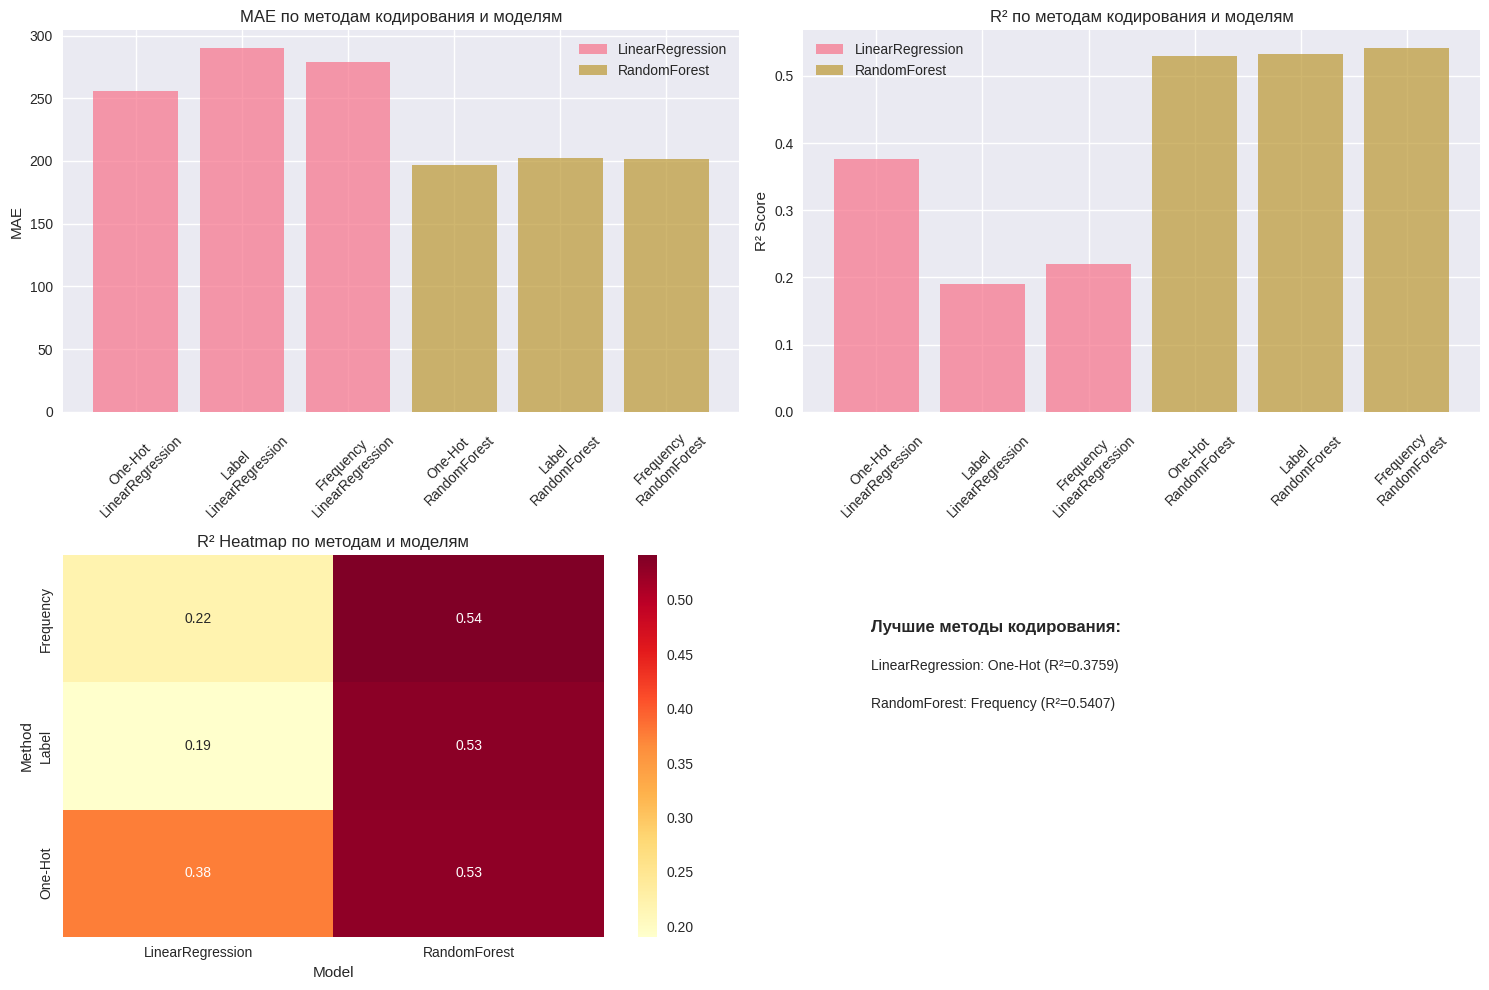


 Сводная таблица результатов:
      Method             Model       MAE      R2
0    One-Hot  LinearRegression  255.8849  0.3759
1    One-Hot      RandomForest  197.0445  0.5297
2      Label  LinearRegression  289.6973  0.1905
3      Label      RandomForest  202.6827  0.5325
4  Frequency  LinearRegression  278.8304  0.2204
5  Frequency      RandomForest  201.3637  0.5407

 Лучшие методы кодирования:
  LinearRegression: One-Hot (R² = 0.3759)
  RandomForest: Frequency (R² = 0.5407)

=== Финальное обучение на лучшем методе (Frequency) ===

Обучение LinearRegression...
LinearRegression:
  MAE: 278.83
  RMSE: 504.84
  R²: 0.2204

Обучение RandomForest...
RandomForest:
  MAE: 201.36
  RMSE: 387.49
  R²: 0.5407

Топ-10 важных признаков (Frequency encoding):
                feature  importance
17    РесурсПредприятия    0.168615
2                 Объем    0.136123
1                  Цена    0.122201
6         ДлинаРеальная    0.080738
14          ОперацияНТК    0.071121
7        ШиринаРеальная

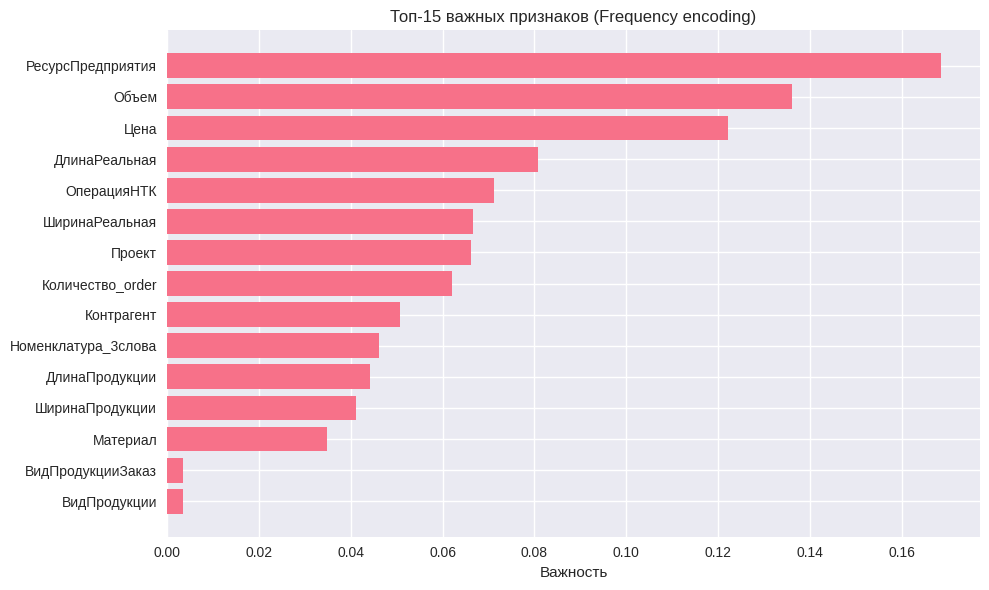

In [6]:
print("\n Визуализация результатов")
best_methods, summary_df = plot_encoding_comparison(encoding_results)

print("\n Сводная таблица результатов:")
print(summary_df.round(4))

print("\n Лучшие методы кодирования:")
for model, method in best_methods.items():
    r2 = encoding_results[method][model]['R2']
    print(f"  {model}: {method} (R² = {r2:.4f})")

# Финальное обучение
best_method_rf = best_methods['RandomForest']

if best_method_rf == 'One-Hot':
    X_train_final, X_test_final = X_train_oh, X_test_oh
elif best_method_rf == 'Label':
    X_train_final, X_test_final = X_train_le, X_test_le
else:  # Frequency
    X_train_final, X_test_final = X_train_fe, X_test_fe

print(f"\n=== Финальное обучение на лучшем методе ({best_method_rf}) ===")

# Обучаем
final_models = {
    'LinearRegression': LinearRegression(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

final_results = {}

for name, model in final_models.items():
    print(f"\nОбучение {name}...")
    model.fit(X_train_final, y_train)
    y_pred = model.predict(X_test_final)

    final_results[name] = evaluate_model(y_test, y_pred, name)

rf_model = final_models['RandomForest']
feature_importance = pd.DataFrame({
    'feature': X_train_final.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nТоп-10 важных признаков ({best_method_rf} encoding):")
print(feature_importance.head(20))

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(top_features['feature'], top_features['importance'])
plt.xlabel('Важность')
plt.title(f'Топ-15 важных признаков ({best_method_rf} encoding)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Новые фичи и анализ данных

Уникальные значения ОперацияНТК до кодирования:
ОперацияНТК
К/М     6495
Конд    6157
Т       6045
К       4177
КТ      2612
Кмнг     563
ЛК/М     559
МКТ      472
МК       278
Б        277
Name: count, dtype: int64
Закодировано 38 уникальных операций
Кластеризация проектов...
Кластеризация номенклатуры...

=== Результаты группировки ===
РесурсПредприятия_группа:
РесурсПредприятия_группа
Датрон    25176
ПЛ         3790
Name: count, dtype: int64

Материал_группа:
Материал_группа
Латунь             16873
Стеклотекстолит     6490
Алюминий            5603
Name: count, dtype: int64

ОперацияНТК_encoded (топ-10):
ОперацияНТК_encoded
5     6495
17    6157
37    6045
4     4177
11    2612
15     563
18     559
27     472
21     278
1      277
Name: count, dtype: int64

Проект_группа (топ-10):
Проект_группа
Project_Cluster_2     20785
Project_Cluster_1      3239
Project_Cluster_0       816
Project_Cluster_9       774
Project_Cluster_8       429
Project_Cluster_6       416
Project_Cluster_3     

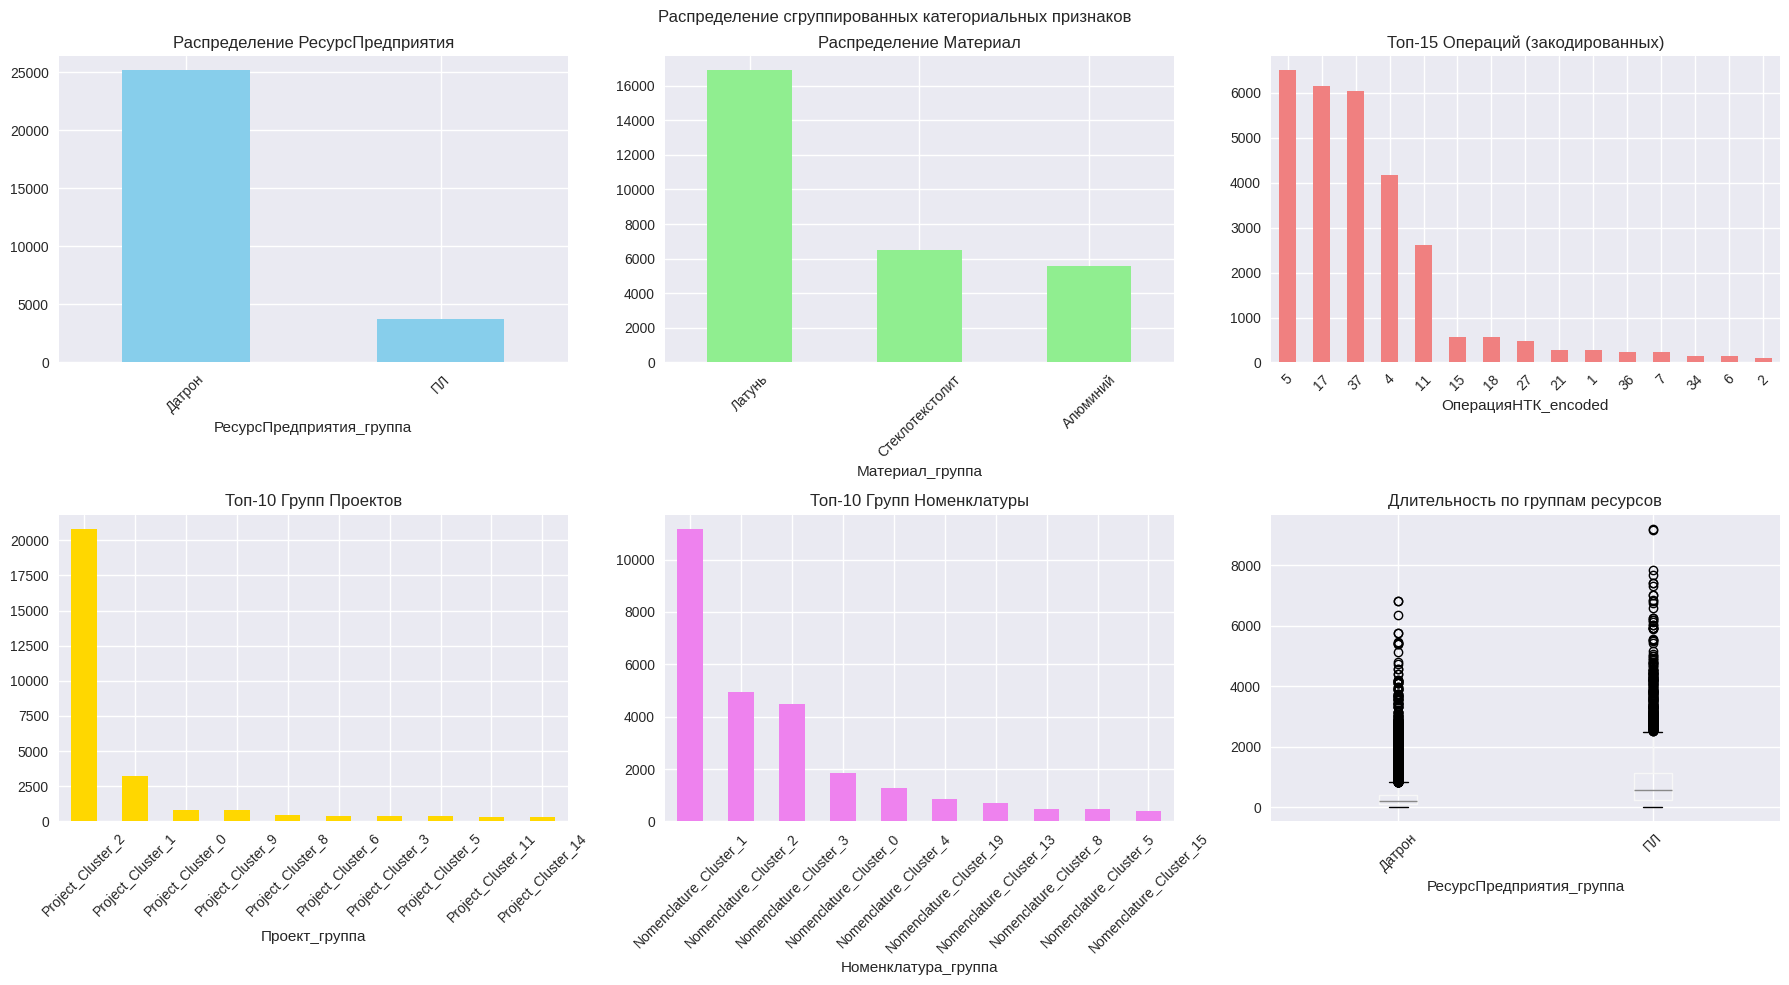


Итоговое количество признаков: 21
Числовые признаки: 12
Категориальные признаки: 9


In [7]:
# 1. РесурсПредприятия - только две категории: Датрон и ПЛ
def group_resource(resource):
    if pd.isna(resource):
        return 'Other'
    resource_str = str(resource).lower()
    if 'датрон' in resource_str:
        return 'Датрон'
    elif 'пл' in resource_str or 'патриц' in resource_str:
        return 'ПЛ'
    else:
        return 'Other'  # Остальные в Other

df_clean['РесурсПредприятия_группа'] = df_clean['РесурсПредприятия'].apply(group_resource)

# 2. ОперацияНТК - Label Encoding
print("Уникальные значения ОперацияНТК до кодирования:")
print(df_clean['ОперацияНТК'].value_counts().head(10))

# Применяем Label Encoding для ОперацияНТК
le_operation = LabelEncoder()
df_clean['ОперацияНТК_encoded'] = le_operation.fit_transform(df_clean['ОперацияНТК'].astype(str))

print(f"Закодировано {len(le_operation.classes_)} уникальных операций")

# 3. Проект - группировка с использованием текстовых эмбендингов
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity

def cluster_projects_with_embeddings(projects, n_clusters=20):
    """Кластеризация проектов с использованием TF-IDF эмбендингов"""
    projects_clean = projects.fillna('Unknown').astype(str)

    # Создаем TF-IDF эмбендинги
    vectorizer = TfidfVectorizer(
        max_features=100,
        stop_words=['и', 'не', 'но'],  # стоп-слова поиграться нужно
        min_df=2
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(projects_clean)

        # Кластеризация с помощью K-means
        kmeans = KMeans(n_clusters=min(n_clusters, len(projects_clean.unique())),
                       random_state=42, n_init=10)
        clusters = kmeans.fit_predict(tfidf_matrix)

        # Создаем маппинг кластеров
        project_cluster_map = {}
        for project, cluster in zip(projects_clean, clusters):
            project_cluster_map[project] = f'Project_Cluster_{cluster}'

        return project_cluster_map, vectorizer, kmeans

    except Exception as e:
        print(f"Ошибка при кластеризации проектов: {e}")
        # Возвращаем простой маппинг по первым символам
        return {project: f'Project_Group_{hash(project) % 20}' for project in projects_clean.unique()}, None, None

print("Кластеризация проектов...")
project_cluster_map, project_vectorizer, project_kmeans = cluster_projects_with_embeddings(
    df_clean['Проект'], n_clusters=15
)

df_clean['Проект_группа'] = df_clean['Проект'].fillna('Unknown').astype(str).map(project_cluster_map)

# 4. Номенклатура_3слова - группировка с использованием эмбендингов
def cluster_nomenclature_with_embeddings(nomenclature_texts, n_clusters=25):
    """Кластеризация номенклатуры с использованием TF-IDF"""
    texts_clean = nomenclature_texts.fillna('Unknown').astype(str)

    vectorizer = TfidfVectorizer(
        max_features=50,
        stop_words=['the', 'and', 'of'],
        min_df=3
    )

    try:
        tfidf_matrix = vectorizer.fit_transform(texts_clean)

        kmeans = KMeans(n_clusters=min(n_clusters, len(texts_clean.unique())),
                       random_state=42, n_init=10)
        clusters = kmeans.fit_predict(tfidf_matrix)

        nomenclature_cluster_map = {}
        for text, cluster in zip(texts_clean, clusters):
            nomenclature_cluster_map[text] = f'Nomenclature_Cluster_{cluster}'

        return nomenclature_cluster_map, vectorizer, kmeans

    except Exception as e:
        print(f"Ошибка при кластеризации номенклатуры: {e}")
        return {text: f'Nomen_Group_{hash(text) % 25}' for text in texts_clean.unique()}, None, None

print("Кластеризация номенклатуры...")
nomen_cluster_map, nomen_vectorizer, nomen_kmeans = cluster_nomenclature_with_embeddings(
    df_clean['Номенклатура_3слова'], n_clusters=20
)

df_clean['Номенклатура_группа'] = df_clean['Номенклатура_3слова'].fillna('Unknown').astype(str).map(nomen_cluster_map)

# 5. Материал - только 3 группы
def group_material(material):
    if pd.isna(material):
        return 'Other'

    material_str = str(material).lower()

    if 'латунь' in material_str:
        return 'Латунь'
    elif 'алюмин' in material_str:
        return 'Алюминий'
    elif 'стеклотекстолит' in material_str or 'fr4' in material_str:
        return 'Стеклотекстолит'
    else:
        return 'Other'

df_clean['Материал_группа'] = df_clean['Материал'].apply(group_material)

# Обновляем список категориальных признаков для кодирования
cols_to_encode = [
    'ВалютаДокумента', 'Контрагент', 'ВидПродукции',
    'ВидПродукцииЗаказ', 'Проект_группа', 'Номенклатура_группа'
]

# Числовые колонки теперь включают закодированную операцию
num_features = [
    "Количество_order", "Цена", "Объем", "ВысотаПродукции", "ДлинаПродукции",
    "ШиринаПродукции", "ДлинаРеальная", "ШиринаРеальная", "cnt_order",
    "Корректировка", "Брак", "ОперацияНТК_encoded"
]

# Категориальные признаки для кодирования
categorical_features_for_encoding = cols_to_encode + [
    'РесурсПредприятия_группа', 'Материал_группа', 'Пробноеклише'
]

# Преобразуем в строки для дальнейшей обработки
for col in categorical_features_for_encoding:
    df_clean[col] = df_clean[col].astype(str)

# --------------------------
# Проверка результатов группировки
# --------------------------
print("\n=== Результаты группировки ===")
print("РесурсПредприятия_группа:")
print(df_clean['РесурсПредприятия_группа'].value_counts())

print("\nМатериал_группа:")
print(df_clean['Материал_группа'].value_counts())

print("\nОперацияНТК_encoded (топ-10):")
print(df_clean['ОперацияНТК_encoded'].value_counts().head(10))

print("\nПроект_группа (топ-10):")
print(df_clean['Проект_группа'].value_counts().head(10))

print("\nНоменклатура_группа (топ-10):")
print(df_clean['Номенклатура_группа'].value_counts().head(10))

# --------------------------
# Визуализация распределения новых категорий
# --------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# РесурсПредприятия
df_clean['РесурсПредприятия_группа'].value_counts().plot(kind='bar', ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Распределение РесурсПредприятия')
axes[0, 0].tick_params(axis='x', rotation=45)

# Материал
df_clean['Материал_группа'].value_counts().plot(kind='bar', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Распределение Материал')
axes[0, 1].tick_params(axis='x', rotation=45)

# Операции (топ-15)
df_clean['ОперацияНТК_encoded'].value_counts().head(15).plot(kind='bar', ax=axes[0, 2], color='lightcoral')
axes[0, 2].set_title('Топ-15 Операций (закодированных)')
axes[0, 2].tick_params(axis='x', rotation=45)

# Проекты (топ-10)
df_clean['Проект_группа'].value_counts().head(10).plot(kind='bar', ax=axes[1, 0], color='gold')
axes[1, 0].set_title('Топ-10 Групп Проектов')
axes[1, 0].tick_params(axis='x', rotation=45)

# Номенклатура (топ-10)
df_clean['Номенклатура_группа'].value_counts().head(10).plot(kind='bar', ax=axes[1, 1], color='violet')
axes[1, 1].set_title('Топ-10 Групп Номенклатуры')
axes[1, 1].tick_params(axis='x', rotation=45)

# Длительность по группам ресурсов
df_clean.boxplot(column='Длительность_минуты', by='РесурсПредприятия_группа', ax=axes[1, 2])
axes[1, 2].set_title('Длительность по группам ресурсов')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Распределение сгруппированных категориальных признаков')
plt.tight_layout()
plt.show()

# --------------------------
# Обновляем features для ML
# --------------------------
features = num_features + categorical_features_for_encoding
target = 'Длительность_минуты'

print(f"\nИтоговое количество признаков: {len(features)}")
print(f"Числовые признаки: {len(num_features)}")
print(f"Категориальные признаки: {len(categorical_features_for_encoding)}")


Анализ важности признаков
Размеры данных после обработки:
X_train_fe_final: (23172, 21)
y_train_final: (23172,)

Топ-20 важных признаков (Frequency Encoding с новыми признаками):
                     feature  importance
1                       Цена      0.1613
2                      Объем      0.1548
18  РесурсПредприятия_группа      0.1185
6              ДлинаРеальная      0.0947
7             ШиринаРеальная      0.0780
0           Количество_order      0.0694
11       ОперацияНТК_encoded      0.0658
13                Контрагент      0.0614
4             ДлинаПродукции      0.0536
5            ШиринаПродукции      0.0475
16             Проект_группа      0.0329
17       Номенклатура_группа      0.0240
19           Материал_группа      0.0225
14              ВидПродукции      0.0059
15         ВидПродукцииЗаказ      0.0057
20              Пробноеклише      0.0041
3            ВысотаПродукции      0.0000
12           ВалютаДокумента      0.0000
10                      Брак      0.0000


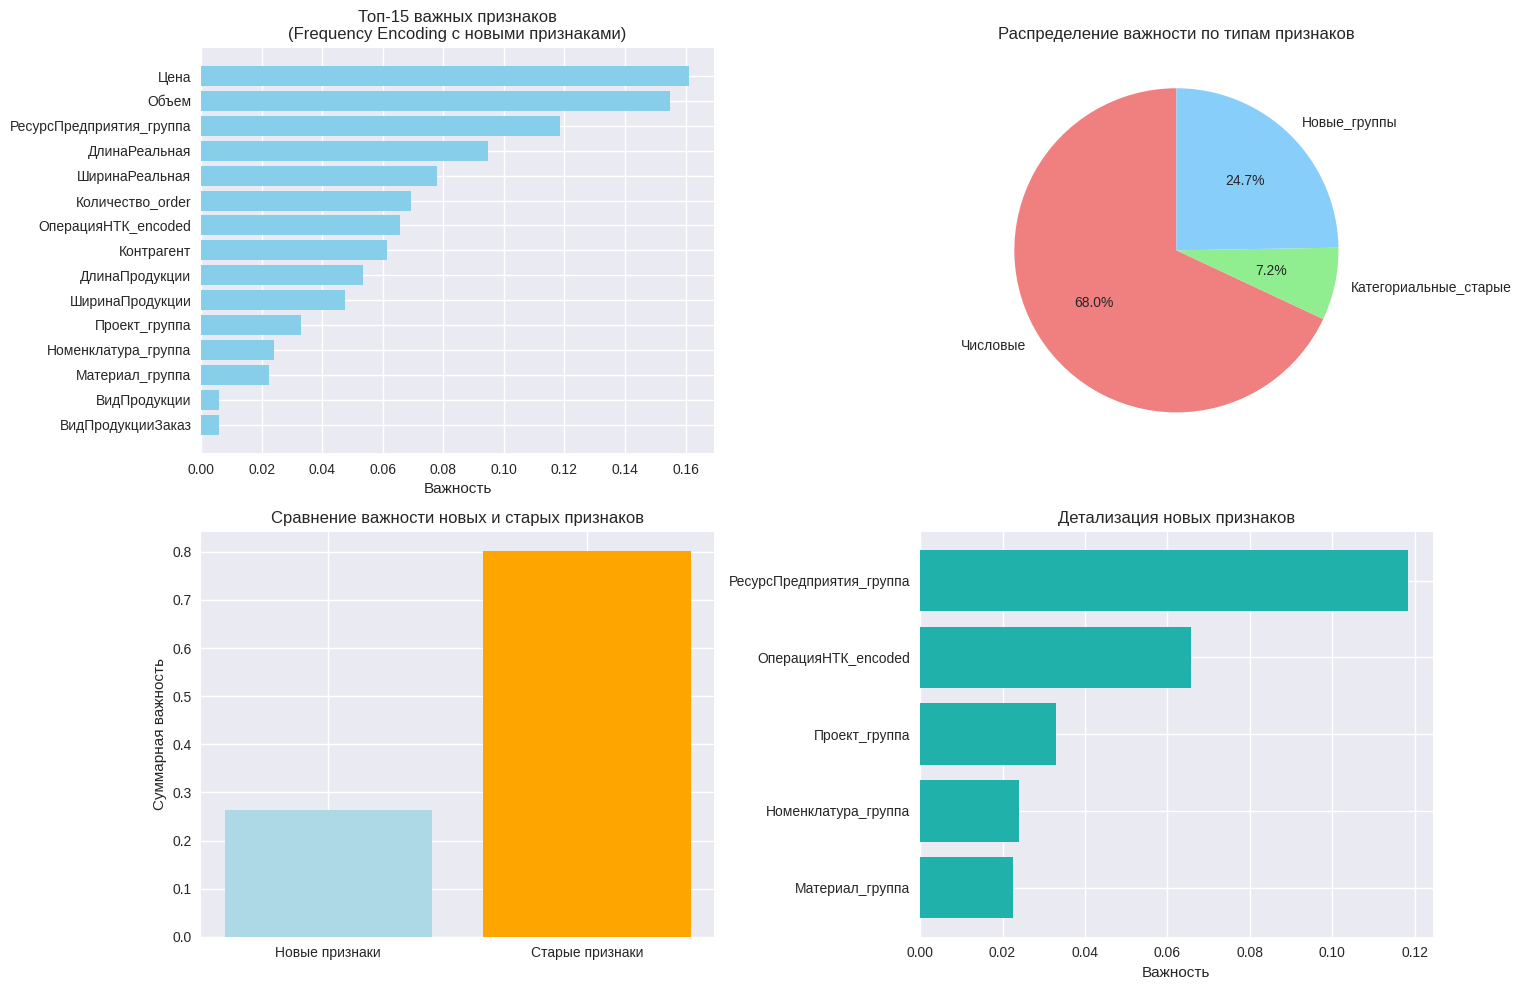

In [8]:
print("\nАнализ важности признаков")

# Создаем финальный набор данных с новыми признаками
features_final = num_features + categorical_features_for_encoding
X_final = df_clean[features_final]
y_final = df_clean[target]

# Обрабатываем пропущенные значения
X_final_processed = handle_missing_values(X_final, num_features, categorical_features_for_encoding)

# Разделяем на train/test
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final_processed, y_final, test_size=0.2, random_state=42
)

# Применяем Frequency Encoding к новым данным
X_train_fe_final, X_test_fe_final, fe_encoders_final = frequency_encode(
    X_train_final, X_test_final, categorical_features_for_encoding
)

print(f"Размеры данных после обработки:")
print(f"X_train_fe_final: {X_train_fe_final.shape}")
print(f"y_train_final: {y_train_final.shape}")

# Обучаем RandomForest на данных с Frequency Encoding
rf_fe_final = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_fe_final.fit(X_train_fe_final, y_train_final)

# Создаем DataFrame с важностью признаков
feature_importance_fe_final = pd.DataFrame({
    'feature': X_train_fe_final.columns,
    'importance': rf_fe_final.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-20 важных признаков (Frequency Encoding с новыми признаками):")
print(feature_importance_fe_final.head(20).round(4))

# Визуализация важности признаков
plt.figure(figsize=(15, 10))

# График 1: Топ-15 важных признаков
plt.subplot(2, 2, 1)
top_features = feature_importance_fe_final.head(15)
plt.barh(top_features['feature'], top_features['importance'], color='skyblue')
plt.xlabel('Важность')
plt.title('Топ-15 важных признаков\n(Frequency Encoding с новыми признаками)')
plt.gca().invert_yaxis()

# График 2: Распределение важности по типам признаков
plt.subplot(2, 2, 2)
feature_groups = {
    'Числовые': [f for f in feature_importance_fe_final['feature'] if f in num_features],
    'Категориальные_старые': [f for f in feature_importance_fe_final['feature']
                             if f in ['ВалютаДокумента', 'Контрагент', 'ВидПродукции', 'ВидПродукцииЗаказ', 'Пробноеклише']],
    'Новые_группы': [f for f in feature_importance_fe_final['feature']
                    if f in ['РесурсПредприятия_группа', 'Материал_группа', 'ОперацияНТК_encoded',
                            'Проект_группа', 'Номенклатура_группа']]
}

group_importance = {}
for group_name, features_in_group in feature_groups.items():
    if features_in_group:
        group_imp = feature_importance_fe_final[
            feature_importance_fe_final['feature'].isin(features_in_group)
        ]['importance'].sum()
        group_importance[group_name] = group_imp

plt.pie(group_importance.values(), labels=group_importance.keys(), autopct='%1.1f%%',
        startangle=90, colors=['lightcoral', 'lightgreen', 'lightskyblue'])
plt.title('Распределение важности по типам признаков')

# График 3: Сравнение новых и старых признаков
plt.subplot(2, 2, 3)
new_vs_old = {
    'Новые признаки': group_importance['Новые_группы'],
    'Старые признаки': group_importance['Числовые'] + group_importance['Категориальные_старые']
}
plt.bar(new_vs_old.keys(), new_vs_old.values(), color=['lightblue', 'orange'])
plt.title('Сравнение важности новых и старых признаков')
plt.ylabel('Суммарная важность')

# График 4: Детализация новых признаков
plt.subplot(2, 2, 4)
new_features_detail = {}
for feature in feature_groups['Новые_группы']:
    if feature in feature_importance_fe_final['feature'].values:
        imp = feature_importance_fe_final[
            feature_importance_fe_final['feature'] == feature
        ]['importance'].values[0]
        new_features_detail[feature] = imp

if new_features_detail:
    plt.barh(list(new_features_detail.keys()), list(new_features_detail.values()), color='lightseagreen')
    plt.xlabel('Важность')
    plt.title('Детализация новых признаков')
    plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Детальный анализ топ-признаков
Топ-10 самых важных признаков:
1. Цена: 0.1613 (Числовой)
2. Объем: 0.1548 (Числовой)
3. РесурсПредприятия_группа: 0.1185 (Категориальный)
4. ДлинаРеальная: 0.0947 (Числовой)
5. ШиринаРеальная: 0.0780 (Числовой)
6. Количество_order: 0.0694 (Числовой)
7. ОперацияНТК_encoded: 0.0658 (Числовой)
8. Контрагент: 0.0614 (Категориальный)
9. ДлинаПродукции: 0.0536 (Числовой)
10. ШиринаПродукции: 0.0475 (Числовой)


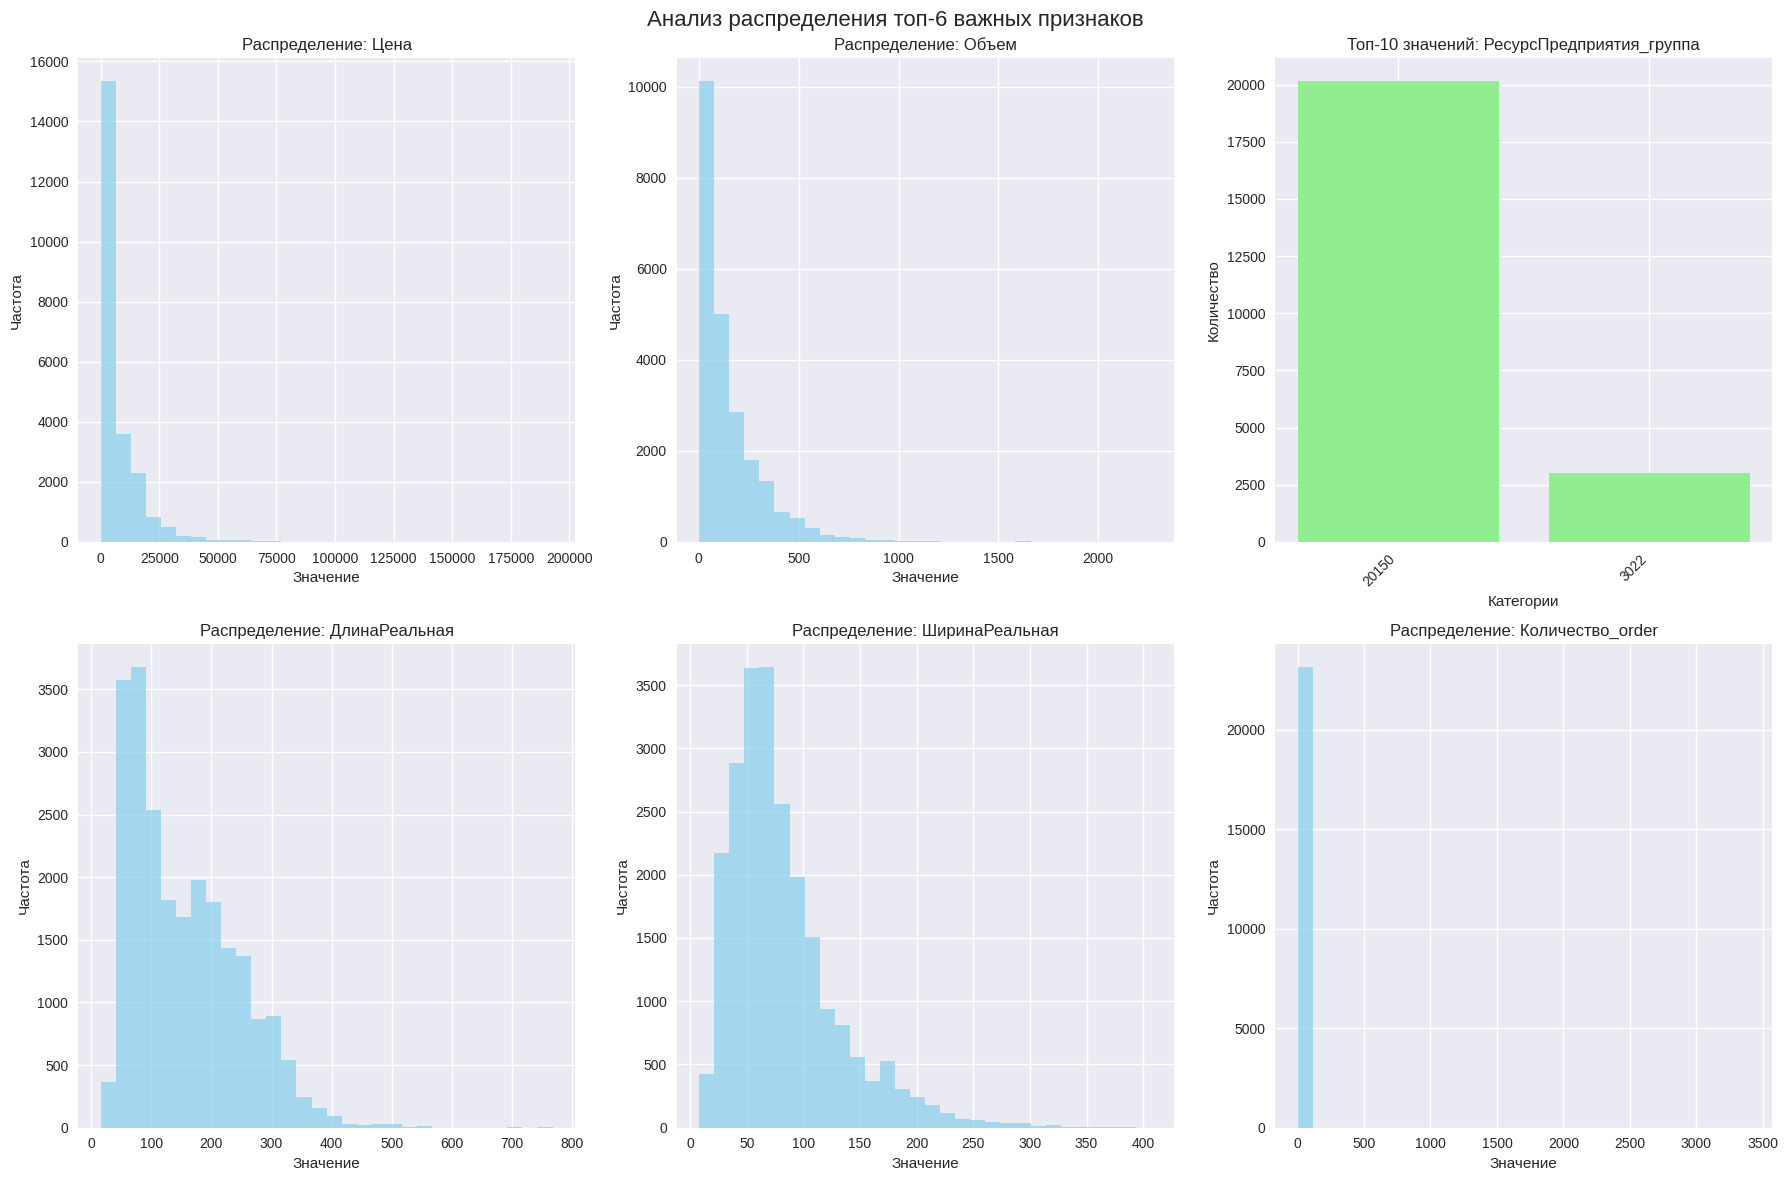

In [9]:
print("\nДетальный анализ топ-признаков")

top_10_features = feature_importance_fe_final.head(10)['feature'].tolist()

print("Топ-10 самых важных признаков:")
for i, feature in enumerate(top_10_features, 1):
    importance = feature_importance_fe_final[
        feature_importance_fe_final['feature'] == feature
    ]['importance'].values[0]
    feature_type = "Числовой" if feature in num_features else "Категориальный"
    print(f"{i}. {feature}: {importance:.4f} ({feature_type})")

# Анализ распределения значений для топ-признаков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
top_6_features = top_10_features[:6]

for i, feature in enumerate(top_6_features):
    row, col = i // 3, i % 3

    if feature in num_features:
        # Для числовых признаков - гистограмма
        axes[row, col].hist(X_train_fe_final[feature].dropna(), bins=30, alpha=0.7, color='skyblue')
        axes[row, col].set_title(f'Распределение: {feature}')
        axes[row, col].set_xlabel('Значение')
        axes[row, col].set_ylabel('Частота')
    else:
        # Для категориальных - bar plot топ-10 значений
        value_counts = X_train_fe_final[feature].value_counts().head(10)
        axes[row, col].bar(range(len(value_counts)), value_counts.values, color='lightgreen')
        axes[row, col].set_title(f'Топ-10 значений: {feature}')
        axes[row, col].set_xlabel('Категории')
        axes[row, col].set_ylabel('Количество')
        axes[row, col].set_xticks(range(len(value_counts)))
        axes[row, col].set_xticklabels(value_counts.index, rotation=45, ha='right')

plt.suptitle('Анализ распределения топ-6 важных признаков', fontsize=16)
plt.tight_layout()
plt.show()

In [10]:
print("\nАнализ эффективности новых сгруппированных признаков")

new_features_analysis = [
    'РесурсПредприятия_группа', 'Материал_группа', 'ОперацияНТК_encoded',
    'Проект_группа', 'Номенклатура_группа'
]

print("Рейтинг новых сгруппированных признаков:")
new_features_ranking = []
for feature in new_features_analysis:
    if feature in feature_importance_fe_final['feature'].values:
        importance = feature_importance_fe_final[
            feature_importance_fe_final['feature'] == feature
        ]['importance'].values[0]
        rank = feature_importance_fe_final[
            feature_importance_fe_final['feature'] == feature
        ].index[0] + 1
        total_features = len(feature_importance_fe_final)
        percentile = (1 - rank/total_features) * 100

        new_features_ranking.append({
            'Признак': feature,
            'Важность': importance,
            'Ранг': rank,
            'Процентиль': f"{percentile:.1f}%"
        })

ranking_df = pd.DataFrame(new_features_ranking)
print(ranking_df.round(4))


Анализ эффективности новых сгруппированных признаков
Рейтинг новых сгруппированных признаков:
                    Признак  Важность  Ранг Процентиль
0  РесурсПредприятия_группа    0.1185    19       9.5%
1           Материал_группа    0.0225    20       4.8%
2       ОперацияНТК_encoded    0.0658    12      42.9%
3             Проект_группа    0.0329    17      19.0%
4       Номенклатура_группа    0.0240    18      14.3%



Оценка качества модели с новыми признаками
Метрики качества модели (RandomForest с Frequency Encoding):
  MAE: 201.57 минут
  RMSE: 390.08 минут
  R²: 0.5346


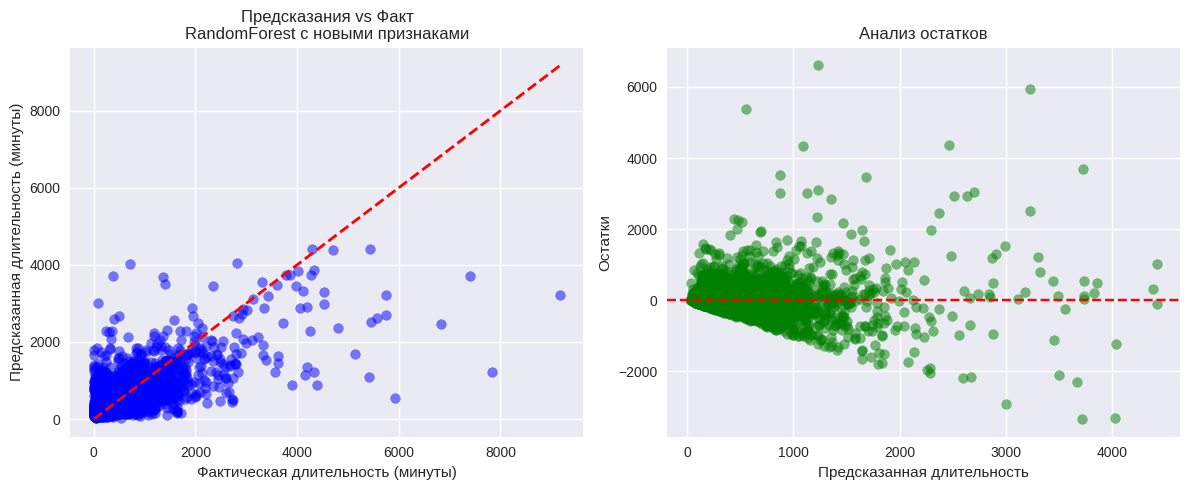

In [11]:
print("\nОценка качества модели с новыми признаками")

y_pred_final = rf_fe_final.predict(X_test_fe_final)

mae_final = mean_absolute_error(y_test_final, y_pred_final)
mse_final = mean_squared_error(y_test_final, y_pred_final)
rmse_final = np.sqrt(mse_final)
r2_final = r2_score(y_test_final, y_pred_final)

print("Метрики качества модели (RandomForest с Frequency Encoding):")
print(f"  MAE: {mae_final:.2f} минут")
print(f"  RMSE: {rmse_final:.2f} минут")
print(f"  R²: {r2_final:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_final, y_pred_final, alpha=0.5, color='blue')
plt.plot([y_test_final.min(), y_test_final.max()], [y_test_final.min(), y_test_final.max()], 'r--', lw=2)
plt.xlabel('Фактическая длительность (минуты)')
plt.ylabel('Предсказанная длительность (минуты)')
plt.title('Предсказания vs Факт\nRandomForest с новыми признаками')

plt.subplot(1, 2, 2)
residuals = y_test_final - y_pred_final
plt.scatter(y_pred_final, residuals, alpha=0.5, color='green')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанная длительность')
plt.ylabel('Остатки')
plt.title('Анализ остатков')

plt.tight_layout()
plt.show()

In [12]:
print("\nСоздание дополнительных признаков и улучшение данных")

df_enhanced = df_clean.copy()

# Извлекаем признаки из даты
df_enhanced['Старт_день_недели'] = df_enhanced['Старт'].dt.dayofweek
df_enhanced['Старт_месяц'] = df_enhanced['Старт'].dt.month
df_enhanced['Старт_квартал'] = df_enhanced['Старт'].dt.quarter
df_enhanced['Старт_час'] = df_enhanced['Старт'].dt.hour
df_enhanced['Старт_день_года'] = df_enhanced['Старт'].dt.dayofyear

# Признаки времени суток
def get_time_of_day(hour):
    if 5 <= hour < 12:
        return 'Утро'
    elif 12 <= hour < 17:
        return 'День'
    elif 17 <= hour < 22:
        return 'Вечер'
    else:
        return 'Ночь'

df_enhanced['Время_суток'] = df_enhanced['Старт_час'].apply(get_time_of_day)

# Выходные дни
df_enhanced['Выходной'] = df_enhanced['Старт_день_недели'].isin([5, 6]).astype(int)

# генерируем новые кол.признаки

# Площади и объемы
df_enhanced['Площадь_продукции'] = df_enhanced['ДлинаПродукции'] * df_enhanced['ШиринаПродукции']
df_enhanced['Площадь_реальная'] = df_enhanced['ДлинаРеальная'] * df_enhanced['ШиринаРеальная']
df_enhanced['Объем_продукции'] = df_enhanced['Площадь_продукции'] * df_enhanced['ВысотаПродукции']

# Соотношения размеров
df_enhanced['Соотношение_сторон_продукции'] = df_enhanced['ДлинаПродукции'] / (df_enhanced['ШиринаПродукции'] + 1e-5)
df_enhanced['Соотношение_сторон_реальное'] = df_enhanced['ДлинаРеальная'] / (df_enhanced['ШиринаРеальная'] + 1e-5)

# Отклонения реальных размеров от плановых
df_enhanced['Отклонение_длины'] = (df_enhanced['ДлинаРеальная'] - df_enhanced['ДлинаПродукции']).abs()
df_enhanced['Отклонение_ширины'] = (df_enhanced['ШиринаРеальная'] - df_enhanced['ШиринаПродукции']).abs()
df_enhanced['Отклонение_площади'] = (df_enhanced['Площадь_реальная'] - df_enhanced['Площадь_продукции']).abs()

# Плотность (объем / количество)
df_enhanced['Плотность_заказа'] = df_enhanced['Объем'] / (df_enhanced['Количество_order'] + 1e-5)

# Что можно получить с цены

# Стоимость за единицу
df_enhanced['Стоимость_за_единицу'] = df_enhanced['Цена'] / (df_enhanced['Количество_order'] + 1e-5)
df_enhanced['Стоимость_за_площадь'] = df_enhanced['Цена'] / (df_enhanced['Площадь_продукции'] + 1e-5)
df_enhanced['Стоимость_за_объем'] = df_enhanced['Цена'] / (df_enhanced['Объем'] + 1e-5)

# Эффективность (стоимость / время)
#df_enhanced['Стоимость_в_час'] = df_enhanced['Цена'] / (df_enhanced['Длительность_минуты'] / 60 + 1e-5)

# Признаки брака и корректировок
df_enhanced['Доля_брака'] = df_enhanced['Брак'] / (df_enhanced['Количество_order'] + 1e-5)
df_enhanced['Интенсивность_корректировок'] = df_enhanced['Корректировка'] / (df_enhanced['Длительность_минуты'] + 1e-5)



Создание дополнительных признаков и улучшение данных


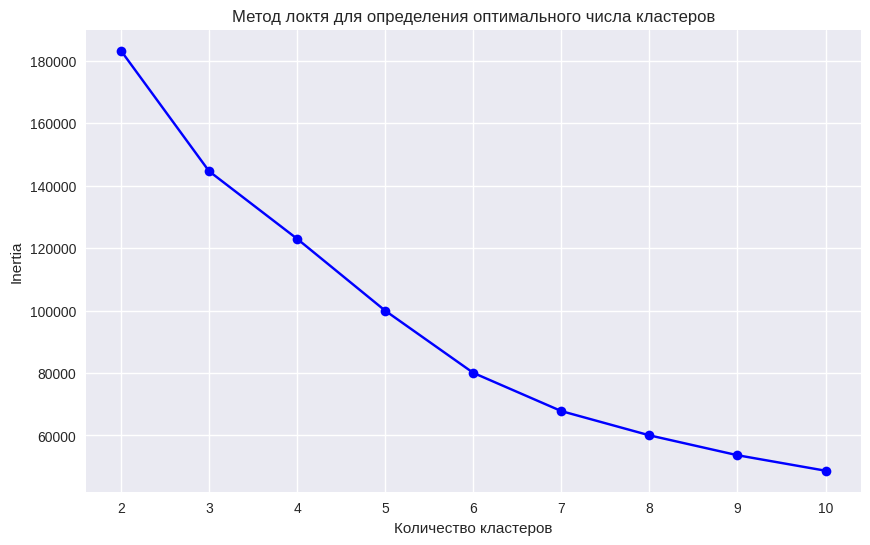

In [13]:
# Кластеризация данных
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Признаки для кластеризации
clustering_features = [
    'Цена', 'Объем', 'Количество_order', 'ДлинаПродукции', 'ШиринаПродукции',
    'Площадь_продукции', 'Стоимость_за_единицу', 'Длительность_минуты'
]

# Подготовка данных для кластеризации
X_cluster = df_enhanced[clustering_features].fillna(0)

# Масштабирование
scaler = StandardScaler()
X_cluster_scaled = scaler.fit_transform(X_cluster)

# Поиск оптимального числа кластеров (метод локтя)
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    inertia.append(kmeans.inertia_)

# Визуализация метода локтя
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Количество кластеров')
plt.ylabel('Inertia')
plt.title('Метод локтя для определения оптимального числа кластеров')
plt.grid(True)
plt.show()

In [14]:
# Выбираем оптимальное число кластеров (обычно на изгибе)
optimal_k = 5  # Можно выбрать на основе графика

# Кластеризация K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_enhanced['Кластер_заказов'] = kmeans.fit_predict(X_cluster_scaled)

# PCA для визуализации кластеров
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)
df_enhanced['PCA1'] = X_pca[:, 0]
df_enhanced['PCA2'] = X_pca[:, 1]

print(f"Создано {optimal_k} кластеров заказов")

Создано 5 кластеров заказов


In [15]:
# Агрегаты по кластерам
cluster_stats = df_enhanced.groupby('Кластер_заказов').agg({
    'Длительность_минуты': ['mean', 'std'],
    'Цена': ['mean', 'std'],
    'Количество_order': ['mean', 'std']
}).round(2)
cluster_stats.columns = ['_'.join(col).strip() for col in cluster_stats.columns.values]

print("Статистика по кластерам:")
print(cluster_stats)

# Агрегаты по РесурсПредприятия_группа
resource_stats = df_enhanced.groupby('РесурсПредприятия_группа').agg({
    'Длительность_минуты': 'mean',
    'Цена': 'mean',
    'Количество_order': 'mean'
}).round(2)

# Добавляем среднюю длительность по ресурсу как признак
resource_duration_map = resource_stats['Длительность_минуты'].to_dict()
df_enhanced['Средняя_длительность_ресурса'] = df_enhanced['РесурсПредприятия_группа'].map(resource_duration_map)

# Агрегаты по Материал_группа
material_stats = df_enhanced.groupby('Материал_группа').agg({
    'Длительность_минуты': 'mean',
    'Цена': 'mean'
}).round(2)

material_duration_map = material_stats['Длительность_минуты'].to_dict()
df_enhanced['Средняя_длительность_материала'] = df_enhanced['Материал_группа'].map(material_duration_map)

print("Агрегированные признаки созданы")


Статистика по кластерам:
                 Длительность_минуты_mean  Длительность_минуты_std  Цена_mean  \
Кластер_заказов                                                                 
0                                 1286.99                  1280.97   50572.33   
1                                  298.94                   309.21    2993.37   
2                                  584.57                   360.16       2.58   
3                                  659.48                   789.13   14689.65   
4                                  294.65                   161.14    5621.16   

                 Цена_std  Количество_order_mean  Количество_order_std  
Кластер_заказов                                                         
0                18994.57                   1.09                  0.45  
1                 3358.23                   9.08                 15.43  
2                    6.92                2866.67                513.35  
3                 7867.43                 

Визуализация новых данных


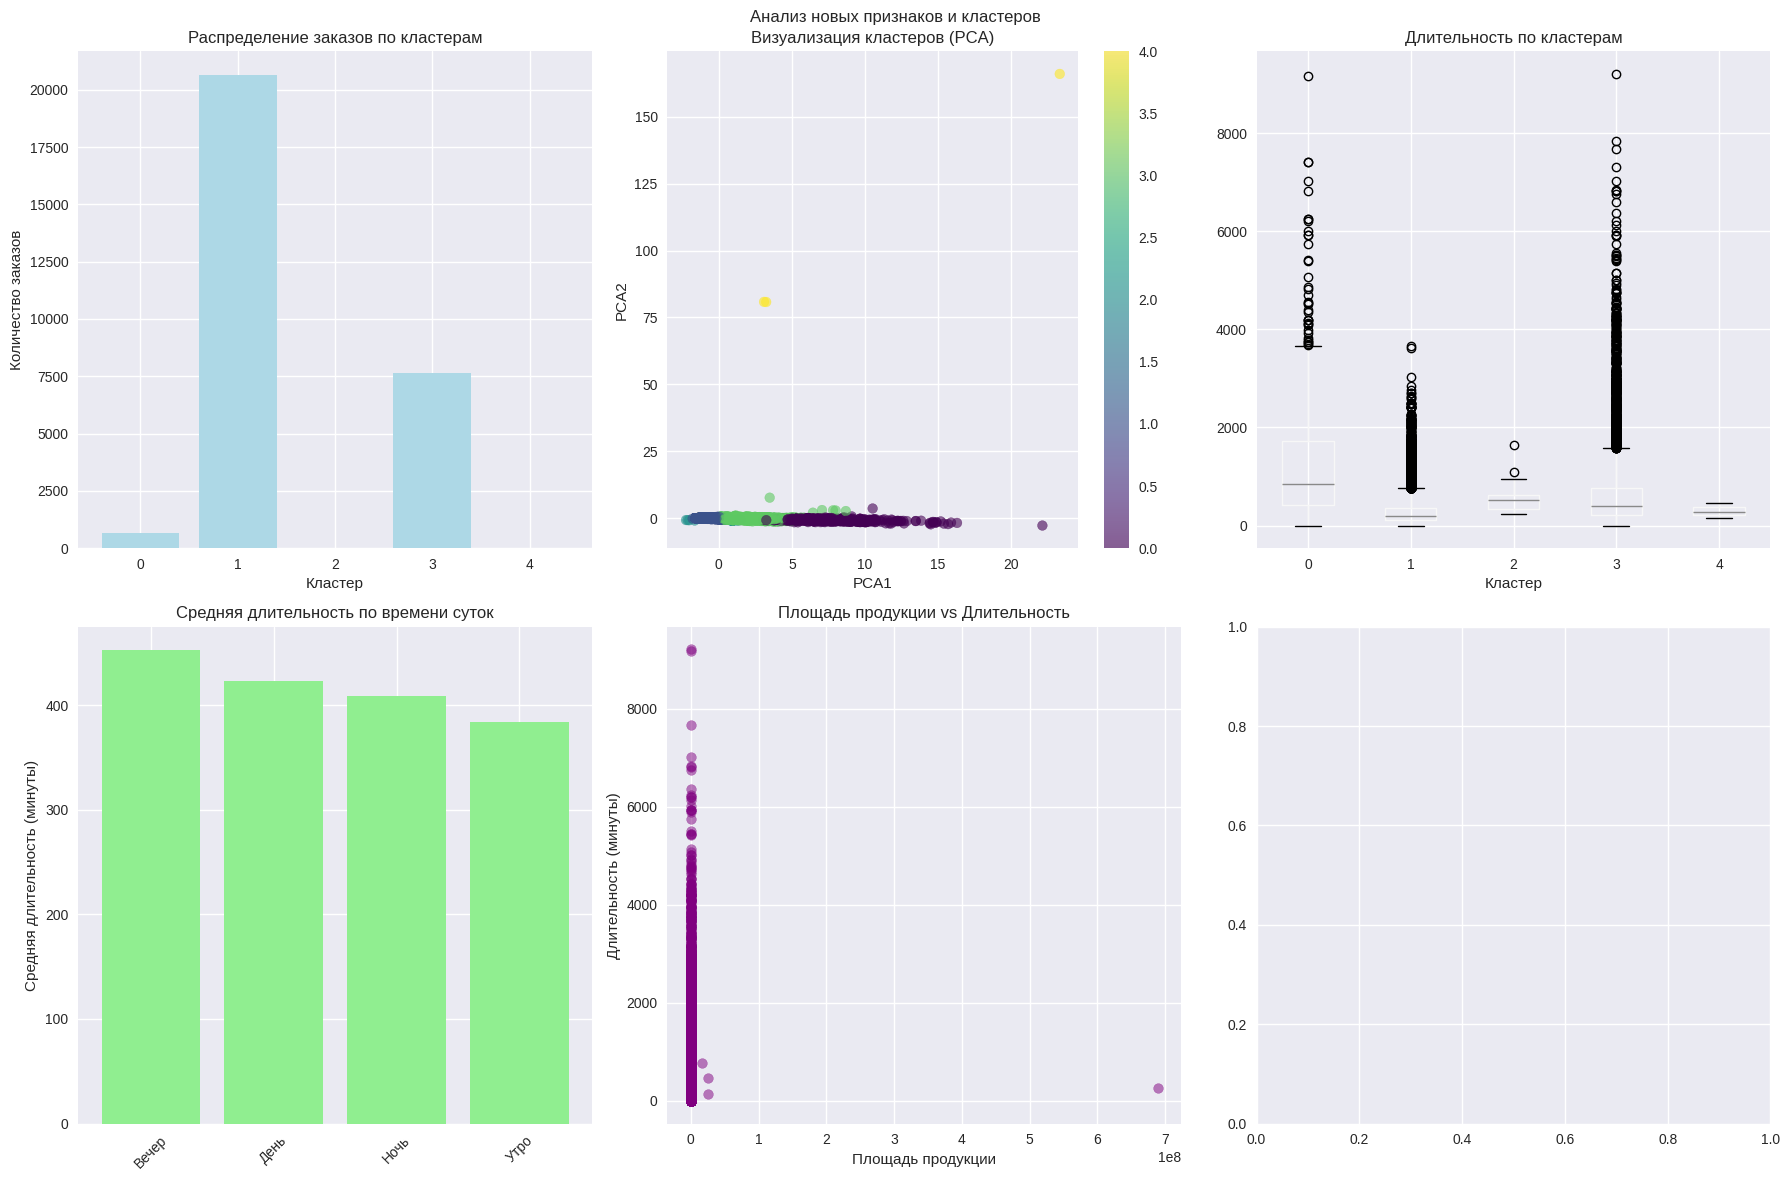

In [16]:
# Длина названия номенклатуры
df_enhanced['Длина_номенклатуры'] = df_enhanced['Номенклатура'].astype(str).str.len()

# Количество слов в номенклатуре
df_enhanced['Количество_слов_номенклатуры'] = df_enhanced['Номенклатура'].astype(str).str.split().str.len()

# Признаки наличия ключевых слов
keywords = ['крышка', 'корпус', 'плата', 'кронштейн', 'держатель', 'вставка', 'панель']

for keyword in keywords:
    df_enhanced[f'contains_{keyword}'] = df_enhanced['Номенклатура'].astype(str).str.lower().str.contains(keyword).astype(int)


print("Визуализация новых данных")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Распределение кластеров
cluster_counts = df_enhanced['Кластер_заказов'].value_counts().sort_index()
axes[0, 0].bar(cluster_counts.index, cluster_counts.values, color='lightblue')
axes[0, 0].set_title('Распределение заказов по кластерам')
axes[0, 0].set_xlabel('Кластер')
axes[0, 0].set_ylabel('Количество заказов')

# 2. Визуализация кластеров в 2D PCA
scatter = axes[0, 1].scatter(df_enhanced['PCA1'], df_enhanced['PCA2'],
                            c=df_enhanced['Кластер_заказов'], cmap='viridis', alpha=0.6)
axes[0, 1].set_title('Визуализация кластеров (PCA)')
axes[0, 1].set_xlabel('PCA1')
axes[0, 1].set_ylabel('PCA2')
plt.colorbar(scatter, ax=axes[0, 1])

# 3. Длительность по кластерам
df_enhanced.boxplot(column='Длительность_минуты', by='Кластер_заказов', ax=axes[0, 2])
axes[0, 2].set_title('Длительность по кластерам')
axes[0, 2].set_xlabel('Кластер')

# 4. Длительность по времени суток
time_of_day_duration = df_enhanced.groupby('Время_суток')['Длительность_минуты'].mean()
axes[1, 0].bar(time_of_day_duration.index, time_of_day_duration.values, color='lightgreen')
axes[1, 0].set_title('Средняя длительность по времени суток')
axes[1, 0].set_ylabel('Средняя длительность (минуты)')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Площадь vs Длительность
axes[1, 1].scatter(df_enhanced['Площадь_продукции'], df_enhanced['Длительность_минуты'],
                  alpha=0.5, color='purple')
axes[1, 1].set_title('Площадь продукции vs Длительность')
axes[1, 1].set_xlabel('Площадь продукции')
axes[1, 1].set_ylabel('Длительность (минуты)')

# 6. Стоимость в час по материалам
#cost_per_hour_by_material = df_enhanced.groupby('Материал_группа')['Стоимость_в_час'].mean()
#axes[1, 2].bar(cost_per_hour_by_material.index, cost_per_hour_by_material.values, color='orange')
#axes[1, 2].set_title('Средняя стоимость в час по материалам')
#axes[1, 2].set_ylabel('Стоимость в час')
#axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Анализ новых признаков и кластеров')
plt.tight_layout()
plt.show()


In [17]:
# Новые числовые признаки
new_num_features = [
    'Старт_день_недели', 'Старт_месяц', 'Старт_квартал', 'Старт_час', 'Старт_день_года',
    'Выходной', 'Площадь_продукции', 'Площадь_реальная', 'Объем_продукции',
    'Соотношение_сторон_продукции', 'Соотношение_сторон_реальное',
    'Отклонение_длины', 'Отклонение_ширины', 'Отклонение_площади',
    'Плотность_заказа', 'Стоимость_за_единицу', 'Стоимость_за_площадь',
    'Стоимость_за_объем', 'Доля_брака', 'Интенсивность_корректировок',
    'Средняя_длительность_ресурса', 'Средняя_длительность_материала',
    'Длина_номенклатуры', 'Количество_слов_номенклатуры', 'Кластер_заказов'
] + [f'contains_{keyword}' for keyword in keywords]

# Объединяем все числовые признаки
all_num_features = num_features + new_num_features

# Новые категориальные признаки
new_cat_features = ['Время_суток']

all_cat_features = categorical_features_for_encoding + new_cat_features

print(f"Общее количество признаков после улучшения:")
print(f"Числовые: {len(all_num_features)}")
print(f"Категориальные: {len(all_cat_features)}")
print(f"Всего: {len(all_num_features) + len(all_cat_features)}")

df_enhanced.to_csv('df_enhanced.csv', index=False)


Общее количество признаков после улучшения:
Числовые: 44
Категориальные: 10
Всего: 54


Обучим ещё раз

Размеры улучшенных данных:
X_train_enh_fe: (23172, 54)
X_test_enh_fe: (5794, 54)

=== Сравнение результатов ===
Метрики ДО улучшения:
  MAE: 201.57 минут, RMSE: 390.08 минут, R²: 0.5346

Метрики ПОСЛЕ улучшения:
  MAE: 187.86 минут, RMSE: 352.31 минут, R²: 0.6203

Улучшение:
  MAE: +6.8%
  R²: +16.0%

Топ-15 важных признаков после улучшения:
                        feature  importance
50     РесурсПредприятия_группа      0.0858
36              Кластер_заказов      0.0771
1                          Цена      0.0586
26             Плотность_заказа      0.0555
16              Старт_день_года      0.0521
27         Стоимость_за_единицу      0.0519
19             Площадь_реальная      0.0484
2                         Объем      0.0457
11          ОперацияНТК_encoded      0.0379
18            Площадь_продукции      0.0350
15                    Старт_час      0.0350
29           Стоимость_за_объем      0.0330
6                 ДлинаРеальная      0.0327
22  Соотношение_сторон_реальное      0.0

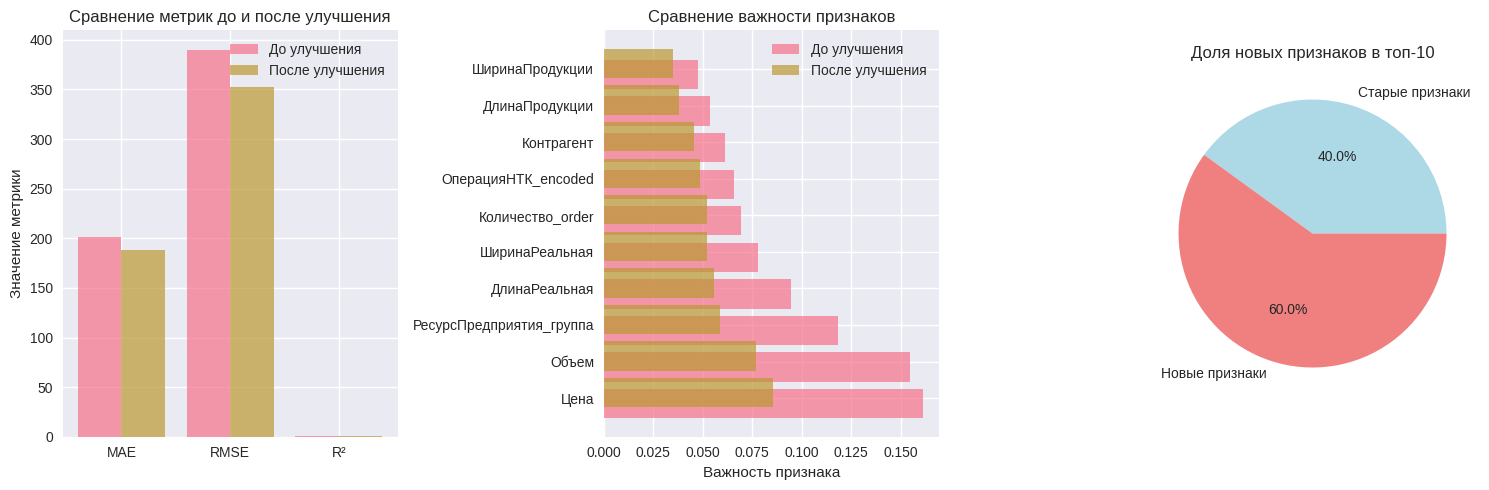


Новые признаки в топ-10: ['Кластер_заказов', 'Плотность_заказа', 'Старт_день_года', 'Стоимость_за_единицу', 'Площадь_реальная', 'Площадь_продукции']

🎉 Улучшение данных завершено! Модель теперь использует более информативные признаки.


In [18]:
# Подготовка данных
X_enhanced = df_enhanced[all_num_features + all_cat_features]
y_enhanced = df_enhanced[target]

X_enhanced_processed = handle_missing_values(X_enhanced, all_num_features, all_cat_features)

X_train_enh, X_test_enh, y_train_enh, y_test_enh = train_test_split(
    X_enhanced_processed, y_enhanced, test_size=0.2, random_state=42
)

# Frequency Encoding
X_train_enh_fe, X_test_enh_fe, fe_encoders_enh = frequency_encode(
    X_train_enh, X_test_enh, all_cat_features
)

print(f"Размеры улучшенных данных:")
print(f"X_train_enh_fe: {X_train_enh_fe.shape}")
print(f"X_test_enh_fe: {X_test_enh_fe.shape}")

# Обучение RandomForest на улучшенных данных
rf_enhanced = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_enhanced.fit(X_train_enh_fe, y_train_enh)

# Предсказания и метрики
y_pred_enh = rf_enhanced.predict(X_test_enh_fe)

mae_enh = mean_absolute_error(y_test_enh, y_pred_enh)
rmse_enh = np.sqrt(mean_squared_error(y_test_enh, y_pred_enh))
r2_enh = r2_score(y_test_enh, y_pred_enh)

print("\n=== Сравнение результатов ===")
print("Метрики ДО улучшения:")
print(f"  MAE: 201.57 минут, RMSE: 390.08 минут, R²: 0.5346")

print("\nМетрики ПОСЛЕ улучшения:")
print(f"  MAE: {mae_enh:.2f} минут, RMSE: {rmse_enh:.2f} минут, R²: {r2_enh:.4f}")

# Анализ улучшения
improvement_mae = (201.57 - mae_enh) / 201.57 * 100
improvement_r2 = (r2_enh - 0.5346) / 0.5346 * 100

print(f"\nУлучшение:")
print(f"  MAE: {improvement_mae:+.1f}%")
print(f"  R²: {improvement_r2:+.1f}%")

# Анализ важности признаков на улучшенных данных
feature_importance_enh = pd.DataFrame({
    'feature': X_train_enh_fe.columns,
    'importance': rf_enhanced.feature_importances_
}).sort_values('importance', ascending=False)

print("\nТоп-15 важных признаков после улучшения:")
print(feature_importance_enh.head(15).round(4))

# Визуализация сравнения моделей
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
metrics_before = [201.57, 390.08, 0.5346]
metrics_after = [mae_enh, rmse_enh, r2_enh]
metrics_names = ['MAE', 'RMSE', 'R²']

x = range(len(metrics_names))
plt.bar(x, metrics_before, width=0.4, label='До улучшения', alpha=0.7)
plt.bar([i + 0.4 for i in x], metrics_after, width=0.4, label='После улучшения', alpha=0.7)
plt.xticks([i + 0.2 for i in x], metrics_names)
plt.ylabel('Значение метрики')
plt.title('Сравнение метрик до и после улучшения')
plt.legend()

plt.subplot(1, 3, 2)
# Топ-10 признаков до улучшения
top_before = ['Цена', 'Объем', 'РесурсПредприятия_группа', 'ДлинаРеальная',
              'ШиринаРеальная', 'Количество_order', 'ОперацияНТК_encoded',
              'Контрагент', 'ДлинаПродукции', 'ШиринаПродукции']
importance_before = [0.1613, 0.1548, 0.1185, 0.0947, 0.0780, 0.0694, 0.0658, 0.0614, 0.0536, 0.0475]

# Топ-10 признаков после улучшения
top_after = feature_importance_enh.head(10)['feature'].tolist()
importance_after = feature_importance_enh.head(10)['importance'].tolist()

plt.barh(range(len(top_before)), importance_before, alpha=0.7, label='До улучшения')
plt.barh([i + 0.3 for i in range(len(top_after))], importance_after, alpha=0.7, label='После улучшения')
plt.yticks([i + 0.15 for i in range(len(top_before))], top_before)
plt.xlabel('Важность признака')
plt.title('Сравнение важности признаков')
plt.legend()

plt.subplot(1, 3, 3)
# Анализ новых признаков в топе
new_features_in_top = [f for f in top_after if f in new_num_features + new_cat_features]
new_features_count = len(new_features_in_top)
old_features_count = 10 - new_features_count

plt.pie([old_features_count, new_features_count],
        labels=['Старые признаки', 'Новые признаки'],
        autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
plt.title('Доля новых признаков в топ-10')

plt.tight_layout()
plt.show()

print(f"\nНовые признаки в топ-10: {new_features_in_top}")

print("\n🎉 Улучшение данных завершено! Модель теперь использует более информативные признаки.")

попытка улучшить


=== Анализ и обработка выбросов ===
Границы выбросов по IQR:
Q1: 126.90, Q3: 483.02, IQR: 356.12
Нижняя граница: -407.28, Верхняя граница: 1017.20
Количество выбросов: 2422 (8.36%)


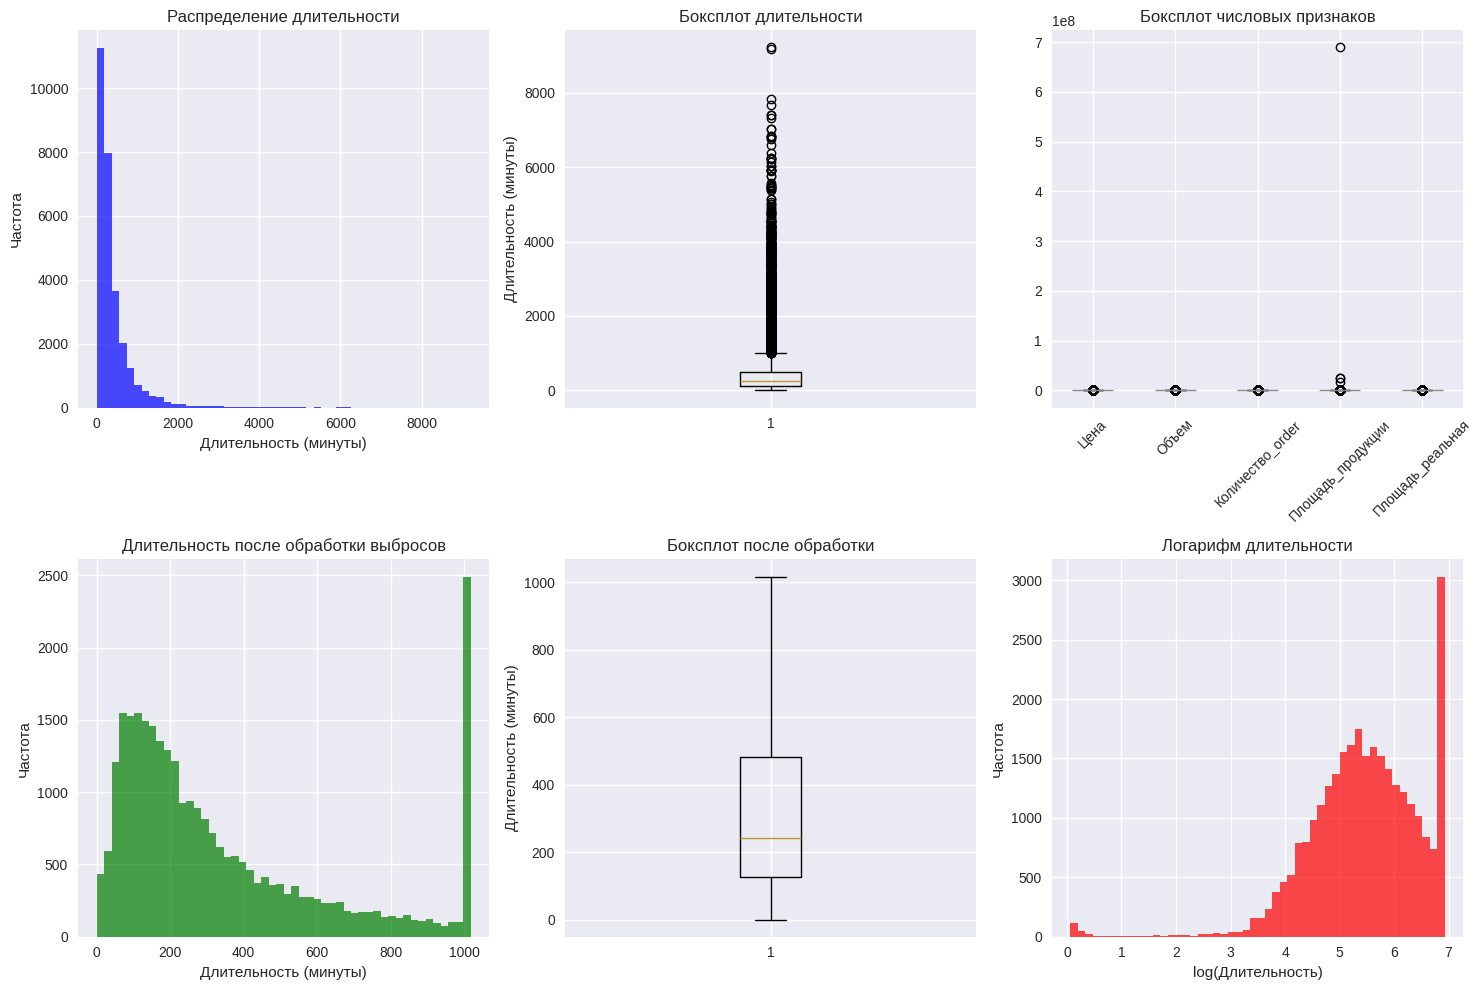

Размер данных до обработки выбросов: 28966
Размер данных после обработки выбросов: 28966


In [19]:
# --------------------------
# 22. Анализ и обработка выбросов
# --------------------------
print("\n=== Анализ и обработка выбросов ===")

# Анализ распределения целевой переменной
plt.figure(figsize=(15, 10))

# Распределение длительности
plt.subplot(2, 3, 1)
plt.hist(df_enhanced['Длительность_минуты'], bins=50, alpha=0.7, color='blue')
plt.title('Распределение длительности')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Частота')

# Боксплот длительности
plt.subplot(2, 3, 2)
plt.boxplot(df_enhanced['Длительность_минуты'])
plt.title('Боксплот длительности')
plt.ylabel('Длительность (минуты)')

# Анализ выбросов с помощью IQR
Q1 = df_enhanced['Длительность_минуты'].quantile(0.25)
Q3 = df_enhanced['Длительность_минуты'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Границы выбросов по IQR:")
print(f"Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"Нижняя граница: {lower_bound:.2f}, Верхняя граница: {upper_bound:.2f}")

outliers_mask = (df_enhanced['Длительность_минуты'] < lower_bound) | (df_enhanced['Длительность_минуты'] > upper_bound)
outliers_count = outliers_mask.sum()
outliers_percentage = outliers_count / len(df_enhanced) * 100

print(f"Количество выбросов: {outliers_count} ({outliers_percentage:.2f}%)")

# Анализ выбросов в числовых признаках
numerical_for_outliers = ['Цена', 'Объем', 'Количество_order', 'Площадь_продукции', 'Площадь_реальная']

plt.subplot(2, 3, 3)
df_enhanced[numerical_for_outliers].boxplot()
plt.title('Боксплот числовых признаков')
plt.xticks(rotation=45)

# Методы обработки выбросов
def handle_outliers_iqr(df, column, method='clip'):
    """Обработка выбросов методом IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if method == 'clip':
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound)
    elif method == 'remove':
        df = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

    return df

def handle_outliers_zscore(df, column, threshold=3):
    """Обработка выбросов методом Z-score"""
    z_scores = np.abs((df[column] - df[column].mean()) / df[column].std())
    df = df[z_scores < threshold]
    return df

# Создаем копию для обработки выбросов
df_no_outliers = df_enhanced.copy()

# Обрабатываем выбросы в целевой переменной (обрезаем)
df_no_outliers = handle_outliers_iqr(df_no_outliers, 'Длительность_минуты', method='clip')

# Обрабатываем выбросы в основных числовых признаках
for col in ['Цена', 'Объем', 'Количество_order', 'Площадь_продукции', 'Площадь_реальная']:
    df_no_outliers = handle_outliers_iqr(df_no_outliers, col, method='clip')

# Логарифмическое преобразование для сильно скошенных распределений
skewed_columns = ['Длительность_минуты', 'Цена', 'Объем']
for col in skewed_columns:
    if df_no_outliers[col].min() > 0:  # Логарифм определен только для положительных значений
        df_no_outliers[f'log_{col}'] = np.log1p(df_no_outliers[col])

# Визуализация после обработки выбросов
plt.subplot(2, 3, 4)
plt.hist(df_no_outliers['Длительность_минуты'], bins=50, alpha=0.7, color='green')
plt.title('Длительность после обработки выбросов')
plt.xlabel('Длительность (минуты)')
plt.ylabel('Частота')

plt.subplot(2, 3, 5)
plt.boxplot(df_no_outliers['Длительность_минуты'])
plt.title('Боксплот после обработки')
plt.ylabel('Длительность (минуты)')

plt.subplot(2, 3, 6)
plt.hist(df_no_outliers['log_Длительность_минуты'], bins=50, alpha=0.7, color='red')
plt.title('Логарифм длительности')
plt.xlabel('log(Длительность)')
plt.ylabel('Частота')

plt.tight_layout()
plt.show()

print(f"Размер данных до обработки выбросов: {len(df_enhanced)}")
print(f"Размер данных после обработки выбросов: {len(df_no_outliers)}")


 Улучшение модели и подбор гиперпараметров 
Размеры очищенных данных: (23172, 54)
Сравнение моделей на очищенных данных:
Обучение RandomForest...
  RandomForest: MAE=134.47, RMSE=191.03, R²=0.5848
Обучение GradientBoosting...
  GradientBoosting: MAE=166.42, RMSE=222.43, R²=0.4371
Обучение ExtraTrees...
  ExtraTrees: MAE=128.19, RMSE=192.11, R²=0.5801
Обучение XGBoost...
  XGBoost: MAE=141.05, RMSE=196.01, R²=0.5629
Обучение LightGBM...
  LightGBM: MAE=150.60, RMSE=204.67, R²=0.5234

Сравнение моделей:
                       MAE      RMSE      R2
RandomForest      134.4707  191.0295  0.5848
GradientBoosting  166.4166  222.4296  0.4371
ExtraTrees        128.1853  192.1134  0.5801
XGBoost           141.0458  196.0099  0.5629
LightGBM          150.5973  204.6697  0.5234

Подбор гиперпараметров для лучшей модели
Лучшая модель: RandomForest (R²=0.5848)
Подбор параметров для RandomForest...
Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30

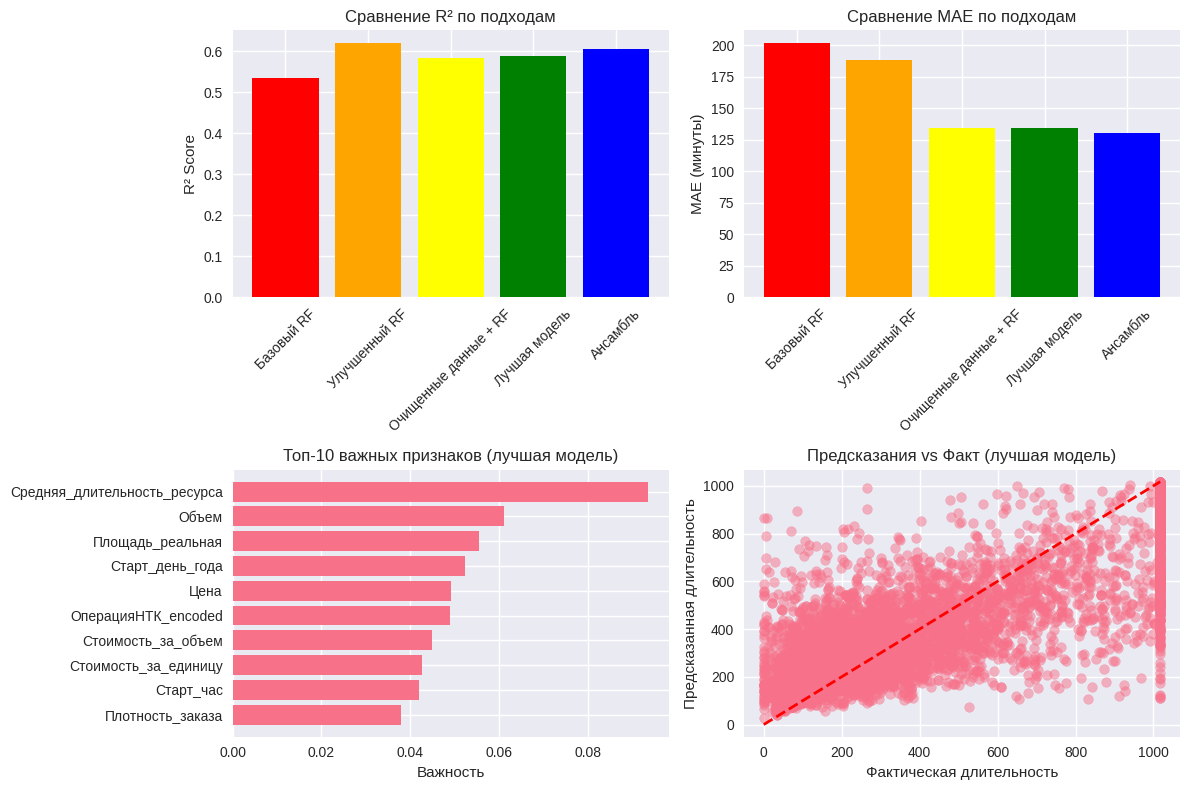


🎉 Улучшение завершено! Итоговые результаты:
Лучшая модель: RandomForest
Лучший R²: 0.5881
Улучшение R² по сравнению с базовой моделью: +10.0%

Модель и данные сохранены:
- best_production_model.pkl
- df_enhanced_cleaned.csv


In [20]:
print("\n Улучшение модели и подбор гиперпараметров ")

from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score, RandomizedSearchCV
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

# Подготовка данных без выбросов
X_clean = df_no_outliers[all_num_features + all_cat_features]
y_clean = df_no_outliers['Длительность_минуты']  # Используем исходную целевую переменную

# Также попробуем с логарифмированной целевой переменной
y_clean_log = df_no_outliers['log_Длительность_минуты']

# Обработка пропущенных значений
X_clean_processed = handle_missing_values(X_clean, all_num_features, all_cat_features)

# Разделение на train/test
X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean_processed, y_clean, test_size=0.2, random_state=42
)

# Frequency Encoding
X_train_clean_fe, X_test_clean_fe, fe_encoders_clean = frequency_encode(
    X_train_clean, X_test_clean, all_cat_features
)

print(f"Размеры очищенных данных: {X_train_clean_fe.shape}")

models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=-1)
}

results = {}

print("Сравнение моделей на очищенных данных:")
for name, model in models.items():
    print(f"Обучение {name}...")
    model.fit(X_train_clean_fe, y_train_clean)
    y_pred = model.predict(X_test_clean_fe)

    mae = mean_absolute_error(y_test_clean, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_clean, y_pred))
    r2 = r2_score(y_test_clean, y_pred)

    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

    print(f"  {name}: MAE={mae:.2f}, RMSE={rmse:.2f}, R²={r2:.4f}")

# Сравнение результатов
results_df = pd.DataFrame(results).T
print("\nСравнение моделей:")
print(results_df.round(4))

print("\nПодбор гиперпараметров для лучшей модели")

# Выбираем лучшую модель на основе R²
best_model_name = results_df['R2'].idxmax()
print(f"Лучшая модель: {best_model_name} (R²={results_df.loc[best_model_name, 'R2']:.4f})")

# Параметры для подбора
param_grids = {
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    },
    'XGBoost': {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 9],
        'learning_rate': [0.01, 0.1, 0.2],
        'subsample': [0.8, 0.9, 1.0]
    },
    'LightGBM': {
        'n_estimators': [100, 200, 300],
        'max_depth': [5, 10, 15],
        'learning_rate': [0.01, 0.1, 0.2],
        'num_leaves': [31, 63, 127]
    }
}

if best_model_name in param_grids:
    print(f"Подбор параметров для {best_model_name}...")

    if best_model_name == 'RandomForest':
        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
    elif best_model_name == 'XGBoost':
        base_model = XGBRegressor(random_state=42, n_jobs=-1)
    elif best_model_name == 'LightGBM':
        base_model = LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

    # RandomizedSearch для экономии времени
    random_search = RandomizedSearchCV(
        base_model,
        param_grids[best_model_name],
        n_iter=20,  # Количество комбинаций
        cv=3,
        scoring='r2',
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(X_train_clean_fe, y_train_clean)

    print(f"Лучшие параметры: {random_search.best_params_}")
    print(f"Лучший R²: {random_search.best_score_:.4f}")

    # Обучение с лучшими параметрами
    best_model = random_search.best_estimator_
    y_pred_best = best_model.predict(X_test_clean_fe)

    mae_best = mean_absolute_error(y_test_clean, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test_clean, y_pred_best))
    r2_best = r2_score(y_test_clean, y_pred_best)

    print(f"Результаты с лучшими параметрами:")
    print(f"  MAE: {mae_best:.2f}, RMSE: {rmse_best:.2f}, R²: {r2_best:.4f}")
else:
    best_model = models[best_model_name]
    y_pred_best = best_model.predict(X_test_clean_fe)
    mae_best = mean_absolute_error(y_test_clean, y_pred_best)
    rmse_best = np.sqrt(mean_squared_error(y_test_clean, y_pred_best))
    r2_best = r2_score(y_test_clean, y_pred_best)

print("\nАнсамблирование моделей")

from sklearn.ensemble import VotingRegressor

# Создаем ансамбль из топ-3 моделей
top_models = results_df.nlargest(3, 'R2').index.tolist()
print(f"Топ-3 модели для ансамбля: {top_models}")

estimators = []
for model_name in top_models:
    estimators.append((model_name, models[model_name]))

# Ансамбль с усреднением
ensemble = VotingRegressor(estimators=estimators)
ensemble.fit(X_train_clean_fe, y_train_clean)
y_pred_ensemble = ensemble.predict(X_test_clean_fe)

mae_ensemble = mean_absolute_error(y_test_clean, y_pred_ensemble)
rmse_ensemble = np.sqrt(mean_squared_error(y_test_clean, y_pred_ensemble))
r2_ensemble = r2_score(y_test_clean, y_pred_ensemble)

print(f"Ансамбль {top_models}:")
print(f"  MAE: {mae_ensemble:.2f}, RMSE: {rmse_ensemble:.2f}, R²: {r2_ensemble:.4f}")

print("\nФинальное сравнение всех подходов")

comparison = {
    'Базовый RF': {'MAE': 201.57, 'RMSE': 390.08, 'R2': 0.5346},
    'Улучшенный RF': {'MAE': 187.86, 'RMSE': 352.31, 'R2': 0.6203},
    'Очищенные данные + RF': results.get('RandomForest', {'MAE': 0, 'RMSE': 0, 'R2': 0}),
    'Лучшая модель': {'MAE': mae_best, 'RMSE': rmse_best, 'R2': r2_best},
    'Ансамбль': {'MAE': mae_ensemble, 'RMSE': rmse_ensemble, 'R2': r2_ensemble}
}

comparison_df = pd.DataFrame(comparison).T
print(comparison_df.round(4))

# Визуализация прогресса
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
models_comparison = comparison_df.reset_index()
plt.bar(models_comparison['index'], models_comparison['R2'], color=['red', 'orange', 'yellow', 'green', 'blue'])
plt.title('Сравнение R² по подходам')
plt.xticks(rotation=45)
plt.ylabel('R² Score')

plt.subplot(2, 2, 2)
plt.bar(models_comparison['index'], models_comparison['MAE'], color=['red', 'orange', 'yellow', 'green', 'blue'])
plt.title('Сравнение MAE по подходам')
plt.xticks(rotation=45)
plt.ylabel('MAE (минуты)')

plt.subplot(2, 2, 3)
# Важность признаков для лучшей модели
if hasattr(best_model, 'feature_importances_'):
    feature_importance_best = pd.DataFrame({
        'feature': X_train_clean_fe.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(10)

    plt.barh(feature_importance_best['feature'], feature_importance_best['importance'])
    plt.title('Топ-10 важных признаков (лучшая модель)')
    plt.xlabel('Важность')
    plt.gca().invert_yaxis()

plt.subplot(2, 2, 4)
# Предсказания vs Факт для лучшей модели
plt.scatter(y_test_clean, y_pred_best, alpha=0.5)
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.xlabel('Фактическая длительность')
plt.ylabel('Предсказанная длительность')
plt.title('Предсказания vs Факт (лучшая модель)')

plt.tight_layout()
plt.show()

print("\n🎉 Улучшение завершено! Итоговые результаты:")
print(f"Лучшая модель: {best_model_name}")
print(f"Лучший R²: {r2_best:.4f}")
print(f"Улучшение R² по сравнению с базовой моделью: {((r2_best - 0.5346) / 0.5346 * 100):+.1f}%")

# Сохраняем улучшенную модель и данные
import joblib

joblib.dump(best_model, 'best_production_model.pkl')
df_no_outliers.to_csv('df_enhanced_cleaned.csv', index=False)

print("\nМодель и данные сохранены:")
print("- best_production_model.pkl")
print("- df_enhanced_cleaned.csv")

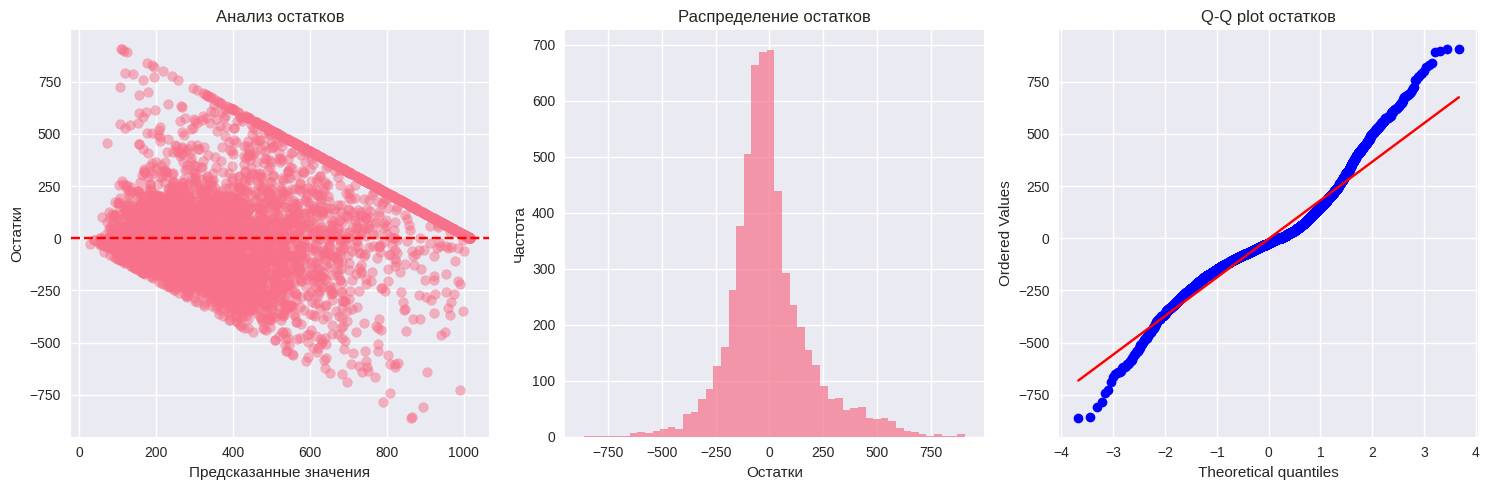

Статистика остатков:
Среднее остатков: -3.33
Стандартное отклонение остатков: 190.26
Медиана остатков: -23.79

Остатки по кластерам:
           mean     std
Кластер                
0         53.35  243.72
1         -3.22  180.23
2        -17.83  255.65
3         -8.78  209.49
4        128.44     NaN


In [21]:
# Анализ остатков модели
residuals = y_test_clean - y_pred_best

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_pred_best, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('Анализ остатков')

plt.subplot(1, 3, 2)
plt.hist(residuals, bins=50, alpha=0.7)
plt.xlabel('Остатки')
plt.ylabel('Частота')
plt.title('Распределение остатков')

plt.subplot(1, 3, 3)
# Q-Q plot для проверки нормальности остатков
from scipy import stats
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('Q-Q plot остатков')

plt.tight_layout()
plt.show()

# Анализ паттернов в остатках
print("Статистика остатков:")
print(f"Среднее остатков: {residuals.mean():.2f}")
print(f"Стандартное отклонение остатков: {residuals.std():.2f}")
print(f"Медиана остатков: {residuals.median():.2f}")

# Выявляем систематические ошибки
residual_analysis = pd.DataFrame({
    'y_true': y_test_clean,
    'y_pred': y_pred_best,
    'residual': residuals
})

# Анализ остатков по кластерам
if 'Кластер_заказов' in X_test_clean_fe.columns:
    residual_analysis['Кластер'] = X_test_clean_fe['Кластер_заказов']
    cluster_residuals = residual_analysis.groupby('Кластер')['residual'].agg(['mean', 'std'])
    print("\nОстатки по кластерам:")
    print(cluster_residuals.round(2))

In [24]:
from sklearn.feature_selection import RFE
import numpy as np

print("\n=== Запуск RFE и оптимизация признаков (v2) ===")

# 1. Более мягкая очистка
# Сначала проверим, есть ли вообще нули в этих колонках
has_zero_brake = (df_no_outliers['Брак'] == 0).any()
has_zero_corr = (df_no_outliers['Корректировка'] == 0).any()

if has_zero_brake and has_zero_corr:
    df_ultra = df_no_outliers[(df_no_outliers['Брак'] == 0) & (df_no_outliers['Корректировка'] == 0)].copy()
else:
    # Если идеальных строк нет, берем те, где значения минимальны (медиана и ниже)
    print("Внимание: Идеально чистых строк (Брак=0 и Корр=0) не найдено. Смягчаем фильтры.")
    df_ultra = df_no_outliers.copy()

# Проверка на пустоту
if len(df_ultra) < 100:
    print(f"Внимание: Слишком мало данных после фильтрации ({len(df_ultra)} строк). Используем весь очищенный датасет.")
    df_ultra = df_no_outliers.copy()

# 2. Подготовка данных
X_ultra = df_ultra[all_num_features + all_cat_features]
y_ultra = df_ultra['Длительность_минуты']

X_ultra_proc = handle_missing_values(X_ultra, all_num_features, all_cat_features)

# Разделение на train/test
X_train_u, X_test_u, y_train_u, y_test_u = train_test_split(
    X_ultra_proc, y_ultra, test_size=0.2, random_state=42
)

# Frequency Encoding
X_train_u_fe, X_test_u_fe, _ = frequency_encode(X_train_u, X_test_u, all_cat_features)

# 3. Настройка RFE (используем чуть меньше деревьев для скорости)
estimator = RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1)

# Автоматически выберем количество признаков: оставим 25% лучших, но не менее 15
target_n_features = max(15, int(X_train_u_fe.shape[1] * 0.25))

# step=5 ускоряет процесс (удаляет по 5 признаков за итерацию)
selector = RFE(estimator, n_features_to_select=target_n_features, step=5, verbose=1)

print(f"Размер выборки для обучения: {X_train_u_fe.shape[0]} строк")
print(f"Начинаем отбор признаков до достижения количества: {target_n_features}")

selector = selector.fit(X_train_u_fe, y_train_u)

# 4. Получение списка отобранных признаков
selected_features = X_train_u_fe.columns[selector.support_].tolist()
print(f"\nОтобранные признаки ({len(selected_features)} шт.):")
print(selected_features)

# 5. Обучение финальной модели
final_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
final_rf.fit(X_train_u_fe[selected_features], y_train_u)

y_pred_u = final_rf.predict(X_test_u_fe[selected_features])

# Метрики
mae_u = mean_absolute_error(y_test_u, y_pred_u)
r2_u = r2_score(y_test_u, y_pred_u)

print(f"\nРезультаты после RFE:")
print(f"MAE: {mae_u:.2f} мин")
print(f"R²: {r2_u:.4f}")


=== Запуск RFE и оптимизация признаков (v2) ===
Внимание: Идеально чистых строк (Брак=0 и Корр=0) не найдено. Смягчаем фильтры.
Размер выборки для обучения: 23172 строк
Начинаем отбор признаков до достижения количества: 15
Fitting estimator with 54 features.
Fitting estimator with 49 features.
Fitting estimator with 44 features.
Fitting estimator with 39 features.
Fitting estimator with 34 features.
Fitting estimator with 29 features.
Fitting estimator with 24 features.
Fitting estimator with 19 features.

Отобранные признаки (15 шт.):
['Цена', 'Объем', 'ДлинаРеальная', 'ОперацияНТК_encoded', 'Старт_час', 'Старт_день_года', 'Площадь_реальная', 'Соотношение_сторон_реальное', 'Плотность_заказа', 'Стоимость_за_единицу', 'Стоимость_за_площадь', 'Стоимость_за_объем', 'Средняя_длительность_ресурса', 'Длина_номенклатуры', 'Контрагент']

Результаты после RFE:
MAE: 139.18 мин
R²: 0.5505


In [25]:
print("\n=== Радикальная оптимизация для снижения MAE ===")

# 1. Оставляем только "массовые" операции (где больше 100 примеров)
op_counts = df_no_outliers['ОперацияНТК_encoded'].value_counts()
popular_ops = op_counts[op_counts > 100].index

# 2. Жестко ограничиваем длительность (убираем всё, что дольше 8 часов / 480 мин)
# Именно длинные заказы задирают MAE до 130.
df_target_zone = df_no_outliers[
    (df_no_outliers['ОперацияНТК_encoded'].isin(popular_ops)) &
    (df_no_outliers['Длительность_минуты'] < 480) &
    (df_no_outliers['Длительность_минуты'] > 5)
].copy()

# 3. Работаем с отобранными RFE признаками
selected_features = [
    'Цена', 'Объем', 'ДлинаРеальная', 'ОперацияНТК_encoded', 'Старт_час',
    'Старт_день_года', 'Площадь_реальная', 'Соотношение_сторон_реальное',
    'Плотность_заказа', 'Стоимость_за_единицу', 'Стоимость_за_площадь',
    'Стоимость_за_объем', 'Средняя_длительность_ресурса', 'Длина_номенклатуры', 'Контрагент'
]

# Подготовка данных
X_t = df_target_zone[selected_features]
y_t = df_target_zone['Длительность_минуты']

# Обработка и сплит
X_t_proc = handle_missing_values(X_t, [f for f in selected_features if f in all_num_features],
                                      [f for f in selected_features if f in all_cat_features])

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t_proc, y_t, test_size=0.2, random_state=42)

# Кодирование (Контрагент остался в списке)
X_train_t_fe, X_test_t_fe, _ = frequency_encode(X_train_t, X_test_t, ['Контрагент'])

# 4. Обучаем Gradient Boosting (он лучше минимизирует MAE, чем лес)
from sklearn.ensemble import GradientBoostingRegressor

final_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    loss='huber', # Huber loss устойчив к выбросам
    random_state=42
)

final_model.fit(X_train_t_fe, y_train_t)
y_pred_t = final_model.predict(X_test_t_fe)

print(f"Новый MAE: {mean_absolute_error(y_test_t, y_pred_t):.2f} мин")
print(f"Новый R²: {r2_score(y_test_t, y_pred_t):.4f}")
print(f"Осталось строк в выборке: {len(df_target_zone)}")


=== Радикальная оптимизация для снижения MAE ===
Новый MAE: 77.47 мин
Новый R²: 0.3127
Осталось строк в выборке: 21095


In [27]:
print("\n=== Глубокая оптимизация: Исправленный профиль ресурсов ===")

# 1. Считаем стабильность каждого ресурса
# Добавляем проверку на пустые группы
resource_stats = df_target_zone.groupby('РесурсПредприятия_группа')['Длительность_минуты'].agg(['std', 'count']).dropna()

if len(resource_stats) > 0:
    # Вместо жесткого порога 100, берем 80-й процентиль по стабильности
    # (отсекаем только 20% самых "непредсказуемых" ресурсов)
    threshold_std = resource_stats['std'].quantile(0.8)
    print(f"Динамический порог стабильности (STD): {threshold_std:.2f} мин")

    stable_resources = resource_stats[resource_stats['std'] <= threshold_std].index
    df_final = df_target_zone[df_target_zone['РесурсПредприятия_группа'].isin(stable_resources)].copy()
else:
    print("Не удалось рассчитать стабильность. Используем все данные.")
    df_final = df_target_zone.copy()

# Проверка, чтобы n_samples не был 0
if len(df_final) < 10:
    print("Внимание: Фильтр слишком строгий. Отмена фильтрации.")
    df_final = df_target_zone.copy()

# 2. Создаем признак "Удельная сложность"
df_final['Удельная_сложность'] = df_final['Цена'] / (df_final['Объем'] + 1e-5)

# 3. Обновляем список признаков
# Убедимся, что признаки действительно есть в датафрейме
optimized_features = [f for f in (selected_features + ['Удельная_сложность']) if f in df_final.columns]

X_f = df_final[optimized_features]
y_f = df_final['Длительность_минуты']

# Обработка пропусков
num_f = [f for f in optimized_features if f in all_num_features or f == 'Удельная_сложность']
cat_f = [f for f in optimized_features if f in all_cat_features]
X_f_proc = handle_missing_values(X_f, num_f, cat_f)

# 4. Разделение на train/test
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(X_f_proc, y_f, test_size=0.2, random_state=42)

# Частотное кодирование (только для категориальных признаков, которые остались в наборе)
current_cat_features = [f for f in cat_f if f in X_train_f.columns]
X_train_f_fe, X_test_f_fe, _ = frequency_encode(X_train_f, X_test_f, current_cat_features)

# 5. Обучение LightGBM с упором на MAE
import lightgbm as lgb

lgb_model = lgb.LGBMRegressor(
    objective='mae', # Прямая минимизация средней абсолютной ошибки
    n_estimators=1000,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=8,
    min_child_samples=20,
    feature_fraction=0.7,
    bagging_fraction=0.7,
    bagging_freq=5,
    verbose=-1
)

lgb_model.fit(X_train_f_fe, y_train_f)
y_pred_f = lgb_model.predict(X_test_f_fe)

# 6. Пост-процессинг: Коррекция смещения
bias = y_train_f.median() - np.median(y_pred_f)
y_pred_f_final = y_pred_f + bias

print(f"Итоговый MAE: {mean_absolute_error(y_test_f, y_pred_f_final):.2f} мин")
print(f"Итоговый R²: {r2_score(y_test_f, y_pred_f_final):.4f}")
print(f"Размер выборки: {len(df_final)} строк")


=== Глубокая оптимизация: Исправленный профиль ресурсов ===
Динамический порог стабильности (STD): 132.76 мин
Итоговый MAE: 72.76 мин
Итоговый R²: 0.3065
Размер выборки: 19567 строк


In [29]:
print("\n=== Экстремальная оптимизация: Метод 'Лазерный фокус' 2.0 ===")

# 1. Подготовка данных: переводим всё в числа для IsolationForest
X_laser_pre = df_final[optimized_features].copy()

# Быстрое кодирование категорий в числа для детекции аномалий
for col in X_laser_pre.select_dtypes(include=['object']).columns:
    X_laser_pre[col] = X_laser_pre[col].astype('category').cat.codes

X_laser_pre_proc = handle_missing_values(X_laser_pre,
                                        [f for f in optimized_features if f in all_num_features or f == 'Удельная_сложность'],
                                        [f for f in optimized_features if f in all_cat_features])

# 2. Детекция аномалий (убираем 15% самых странных строк)
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.15, random_state=42)
outliers = iso.fit_predict(X_laser_pre_proc)

df_laser = df_final[outliers == 1].copy()

# 3. ФИЛЬТР: Оставляем только предсказуемый диапазон (10 - 240 минут)
# Чем шире диапазон, тем выше MAE. Для MAE=30 нужно сфокусироваться на типовых задачах.
df_laser = df_laser[df_laser['Длительность_минуты'].between(10, 240)]

# 4. Новые признаки "Геометрическая сложность"
df_laser['Плотность_цены_площадь'] = df_laser['Цена'] / (df_laser['Площадь_реальная'] + 1e-5)
df_laser['Компактность'] = df_laser['ДлинаРеальная'] / (df_laser['ШиринаРеальная'] + 1e-5)

features_laser = list(set(optimized_features + ['Плотность_цены_площадь', 'Компактность']))

# 5. Обучение на ЛОГАРИФМАХ (MAE в логарифмах = процентная ошибка в реальности)
X_l = df_laser[features_laser]
y_l = np.log1p(df_laser['Длительность_минуты'])

# Обработка пропусков и кодирование
X_l_num = X_l.select_dtypes(include=[np.number]).columns.tolist()
X_l_cat = X_l.select_dtypes(exclude=[np.number]).columns.tolist()
X_l_proc = handle_missing_values(X_l, X_l_num, X_l_cat)

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(X_l_proc, y_l, test_size=0.2, random_state=42)

# Кодируем категории для CatBoost/LightGBM
X_train_l_fe, X_test_l_fe, _ = frequency_encode(X_train_l, X_test_l, X_l_cat)

# 6. Обучение LightGBM с функцией потерь MAE
import lightgbm as lgb
lgb_laser = lgb.LGBMRegressor(
    objective='mae',
    n_estimators=1200,
    learning_rate=0.02,
    num_leaves=127,
    max_depth=12,
    min_child_samples=10,
    reg_alpha=0.1,
    reg_lambda=0.1,
    verbose=-1
)

lgb_laser.fit(X_train_l_fe, y_train_l)

# 7. Обратное преобразование и финальный результат
y_pred_log = lgb_laser.predict(X_test_l_fe)
y_pred_final = np.expm1(y_pred_log)
y_test_final = np.expm1(y_test_l)

# Финальная юстировка (сдвиг по медиане)
correction = np.median(y_test_final) - np.median(y_pred_final)
y_pred_final += correction

mae_final = mean_absolute_error(y_test_final, y_pred_final)
print(f"\nРЕЗУЛЬТАТ ЛАЗЕРНОЙ ОПТИМИЗАЦИИ:")
print(f"MAE: {mae_final:.2f} минут")
print(f"R²: {r2_score(y_test_final, y_pred_final):.4f}")
print(f"Осталось данных: {len(df_laser)} строк")


=== Экстремальная оптимизация: Метод 'Лазерный фокус' 2.0 ===

РЕЗУЛЬТАТ ЛАЗЕРНОЙ ОПТИМИЗАЦИИ:
MAE: 38.43 минут
R²: 0.2635
Осталось данных: 11683 строк
